# HAR Trustworthy Prediction Pipeline

**Pipeline:** Data Loading → Preprocessing → Baseline Models → Calibration → Selective Prediction → Drift Detection → Experiments → Explainability

**Metric introduced:** TPS = (Coverage × Selective Accuracy) / (1 + ECE)

In [1]:
import sys
!{sys.executable} -m pip install xgboost scikit-learn seaborn matplotlib pandas numpy shap --quiet
print("✅ All packages installed")


✅ All packages installed


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from scipy import stats
from scipy.special import softmax
from scipy.optimize import minimize_scalar
import xgboost as xgb
import shap

print("✅ All imports successful")
print(f"  sklearn  : {__import__('sklearn').__version__}")
print(f"  xgboost  : {xgb.__version__}")
print(f"  shap     : {shap.__version__}")


✅ All imports successful
  sklearn  : 1.6.1
  xgboost  : 2.1.4
  shap     : 0.49.1


## 1. Data Loading

In [3]:
BASE_PATH = "/Users/aaditgupta/HAR_Project/data/UCI HAR Dataset/"

def load_data(split):
    X = pd.read_csv(f"{BASE_PATH}{split}/X_{split}.txt",
                    delim_whitespace=True, header=None)
    y = pd.read_csv(f"{BASE_PATH}{split}/y_{split}.txt",
                    header=None).squeeze()
    return X, y

X_train, y_train = load_data("train")
X_test,  y_test  = load_data("test")

labels = {1: "Walking", 2: "Walking Upstairs", 3: "Walking Downstairs",
          4: "Sitting", 5: "Standing", 6: "Laying"}
y_train_named = y_train.map(labels)
y_test_named  = y_test.map(labels)

print(f"✅ Data loaded!")
print(f"   Training samples : {X_train.shape[0]}")
print(f"   Test samples     : {X_test.shape[0]}")
print(f"   Features         : {X_train.shape[1]}")
print(f"   Classes          : {list(labels.values())}")


✅ Data loaded!
   Training samples : 7352
   Test samples     : 2947
   Features         : 561
   Classes          : ['Walking', 'Walking Upstairs', 'Walking Downstairs', 'Sitting', 'Standing', 'Laying']


## 2. Preprocessing & EDA

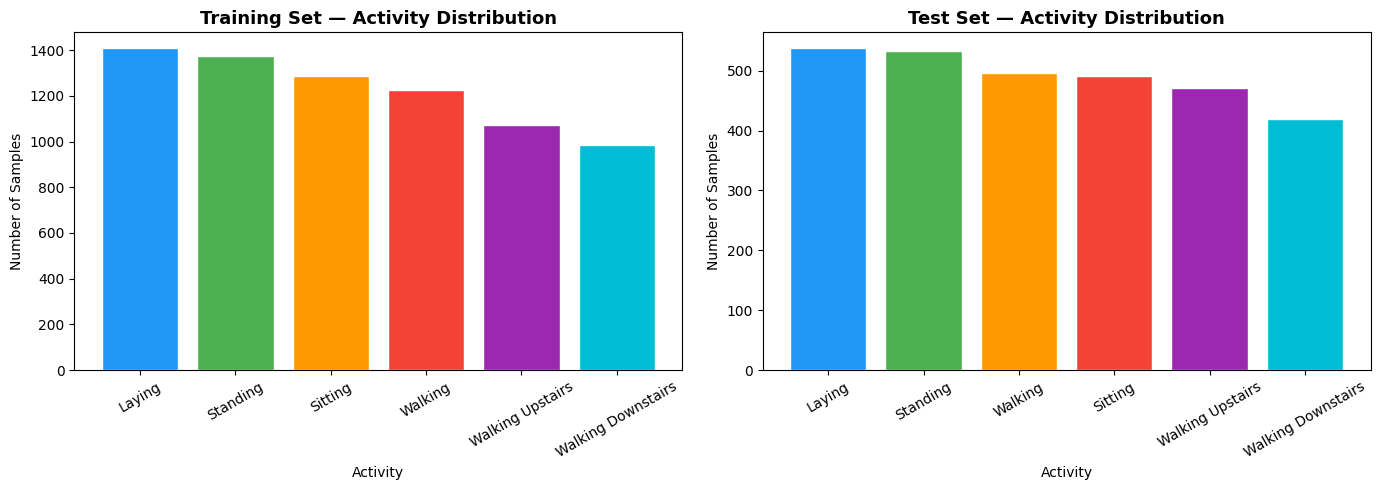

In [4]:
# ── Class distribution ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#2196F3','#4CAF50','#FF9800','#F44336','#9C27B0','#00BCD4']

for ax, named, title in zip(axes,
                             [y_train_named, y_test_named],
                             ["Training Set", "Test Set"]):
    counts = named.value_counts()
    ax.bar(counts.index, counts.values, color=colors, edgecolor='white')
    ax.set_title(f"{title} — Activity Distribution", fontsize=13, fontweight='bold')
    ax.set_xlabel("Activity"); ax.set_ylabel("Number of Samples")
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


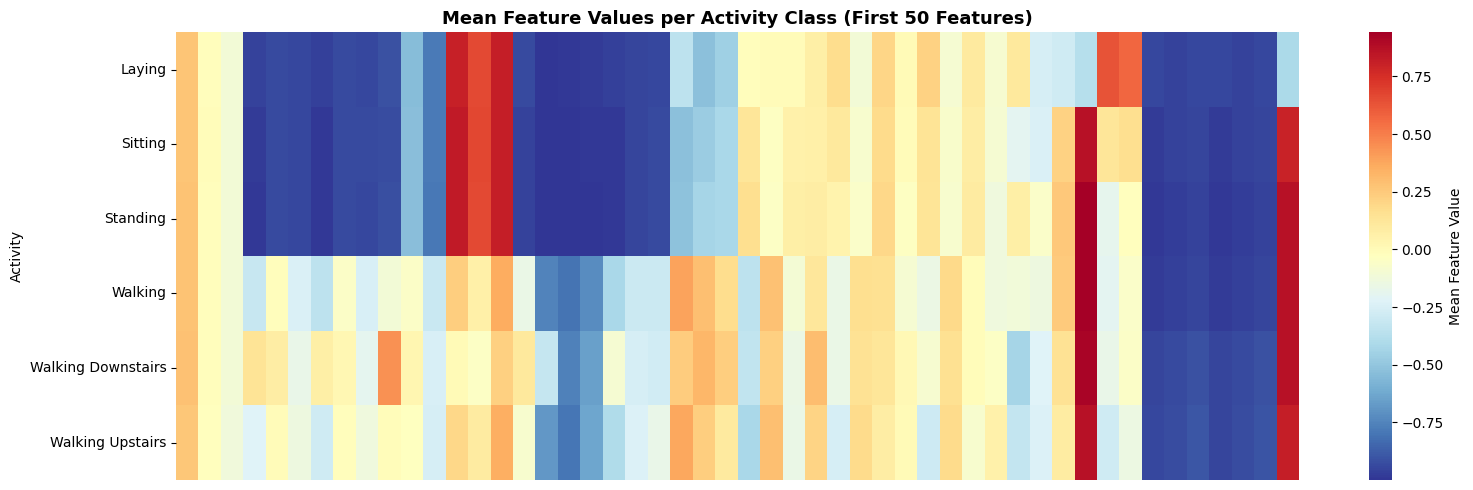

In [5]:
# ── Feature heatmap (first 50 features) ─────────────────────
feature_means = X_train.copy()
feature_means['activity'] = y_train_named.values
class_means = feature_means.groupby('activity').mean().iloc[:, :50]

plt.figure(figsize=(16, 5))
sns.heatmap(class_means, cmap='RdYlBu_r', xticklabels=False,
            yticklabels=True, cbar_kws={'label': 'Mean Feature Value'})
plt.title("Mean Feature Values per Activity Class (First 50 Features)",
          fontsize=13, fontweight='bold')
plt.ylabel("Activity")
plt.tight_layout()
plt.show()


In [6]:
# ── Train/Calibration/Eval split ────────────────────────────
# Calibrate on 30% of test, evaluate on remaining 70%
X_cal, X_eval, y_cal, y_eval = train_test_split(
    X_test, y_test, test_size=0.70, random_state=42, stratify=y_test
)

print(f"Split summary:")
print(f"  Train      : {X_train.shape[0]} samples")
print(f"  Cal        : {len(X_cal)} samples  (30% of test — for calibration)")
print(f"  Eval       : {len(X_eval)} samples  (70% of test — held out)")


Split summary:
  Train      : 7352 samples
  Cal        : 884 samples  (30% of test — for calibration)
  Eval       : 2063 samples  (70% of test — held out)


## 3. Shared Utilities

All reusable functions defined once here and reused throughout the notebook.

In [7]:
# ── ECE ─────────────────────────────────────────────────────
def compute_ece(y_true, y_proba_mat, n_bins=10):
    """
    Expected Calibration Error.
    y_true      : array-like of integer class labels (1-indexed)
    y_proba_mat : (n_samples, n_classes) probability matrix
    """
    confidence = np.max(y_proba_mat, axis=1)
    predicted  = np.argmax(y_proba_mat, axis=1) + 1   # 1-indexed
    correct    = (predicted == np.asarray(y_true))

    bin_edges = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for b in range(n_bins):
        mask = (confidence >= bin_edges[b]) & (confidence < bin_edges[b + 1])
        if mask.sum() > 0:
            ece += mask.sum() * abs(correct[mask].mean() - confidence[mask].mean())
    return ece / len(y_true)


# ── TPS ─────────────────────────────────────────────────────
def compute_tps(coverage, sel_acc, ece):
    """
    Trustworthy Prediction Score.
    TPS = (Coverage × Selective_Accuracy) / (1 + ECE)
    Higher is better. Penalises low coverage AND miscalibration.
    """
    return coverage * sel_acc / (1 + ece)


# ── Reliability diagram ──────────────────────────────────────
def plot_reliability(ax, y_true, y_proba, title, color='#2196F3', n_bins=10):
    """Plot a reliability (calibration) diagram on ax and return ECE."""
    confidence = np.max(y_proba, axis=1)
    predicted  = np.argmax(y_proba, axis=1) + 1
    correct    = (predicted == np.asarray(y_true))

    bin_edges = np.linspace(0, 1, n_bins + 1)
    bin_accs, bin_confs, bin_sizes = [], [], []
    for b in range(n_bins):
        mask = (confidence >= bin_edges[b]) & (confidence < bin_edges[b + 1])
        if mask.sum() > 0:
            bin_accs.append(correct[mask].mean())
            bin_confs.append(confidence[mask].mean())
            bin_sizes.append(mask.sum())

    ece = sum(s * abs(a - c) for a, c, s in zip(bin_accs, bin_confs, bin_sizes)) / len(y_true)

    ax.bar(bin_confs, bin_accs, width=0.08, alpha=0.75,
           color=color, label='Actual Accuracy', edgecolor='white')
    ax.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Perfect')
    ax.fill_between(bin_confs, bin_confs, bin_accs, alpha=0.2, color='red')
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1])
    ax.set_xlabel("Mean Confidence", fontsize=10)
    ax.set_ylabel("Actual Accuracy", fontsize=10)
    ax.set_title(f"{title}\nECE = {ece:.4f}", fontsize=11, fontweight='bold')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
    return ece


# ── Selective prediction engine ───────────────────────────────
def selective_engine(conf_lr, pred_lr, conf_fallback, pred_fallback,
                     y_true, tau_high, tau_low):
    """
    Three-tier selective prediction.

    ACCEPT → conf_lr >= tau_high          : LR prediction used directly
    DEFER  → tau_low <= conf_lr < tau_high: escalate to fallback model
    REJECT → conf_lr < tau_low            : abstain, flag for human review

    Returns a dict with decision array, final_pred, and key metrics
    including TPS = Coverage × Selective_Accuracy / (1 + ECE).
    """
    n = len(conf_lr)
    decision   = np.empty(n, dtype=object)
    final_pred = np.empty(n, dtype=int)

    for i in range(n):
        if conf_lr[i] >= tau_high:
            decision[i]   = 'accept'
            final_pred[i] = pred_lr[i]
        elif conf_lr[i] >= tau_low:
            decision[i]   = 'defer'
            final_pred[i] = pred_fallback[i]
        else:
            decision[i]   = 'reject'
            final_pred[i] = -1

    y_true_arr    = np.asarray(y_true)
    accepted_mask = decision != 'reject'
    covered       = accepted_mask.sum()
    coverage      = covered / n

    if covered > 0:
        sel_acc = (final_pred[accepted_mask] == y_true_arr[accepted_mask]).mean()
    else:
        sel_acc = 0.0

    # ECE on covered predictions
    conf_covered = np.where(decision == 'accept', conf_lr,
                   np.where(decision == 'defer',  conf_fallback, 0.0))
    correct_cov  = (final_pred[accepted_mask] == y_true_arr[accepted_mask])
    conf_cov_vals = conf_covered[accepted_mask]

    ece_sel = 0.0
    if covered > 0:
        bin_edges = np.linspace(0, 1, 11)
        for b in range(10):
            mask = (conf_cov_vals >= bin_edges[b]) & (conf_cov_vals < bin_edges[b + 1])
            if mask.sum() > 0:
                ece_sel += mask.sum() * abs(correct_cov[mask].mean() - conf_cov_vals[mask].mean())
        ece_sel /= covered

    tps = compute_tps(coverage, sel_acc, ece_sel) if covered > 0 else 0.0

    return {
        'decision'   : decision,
        'final_pred' : final_pred,
        'n_accept'   : (decision == 'accept').sum(),
        'n_defer'    : (decision == 'defer').sum(),
        'n_reject'   : (decision == 'reject').sum(),
        'coverage'   : coverage,
        'sel_acc'    : sel_acc,
        'ece_sel'    : ece_sel,
        'tps'        : tps,
    }


# ── Drift detection ──────────────────────────────────────────
def ks_drift(X_ref, X_test_df, ks_threshold=0.10):
    """
    KS drift using statistic threshold (not p-value).
    Robust to large sample size differences.
    ks_threshold=0.10: features with KS stat > 0.10 are flagged.
    """
    ks_stats = np.array([
        stats.ks_2samp(X_ref.iloc[:, f].values, X_test_df.iloc[:, f].values)[0]
        for f in range(X_ref.shape[1])
    ])
    n_drifted = np.sum(ks_stats > ks_threshold)
    return {
        'n_drifted'      : int(n_drifted),
        'drift_fraction' : n_drifted / X_ref.shape[1],
        'mean_ks_stat'   : float(np.mean(ks_stats)),
        'max_ks_stat'    : float(np.max(ks_stats)),
        'ks_stats'       : ks_stats,
    }


def psi_score(X_ref, X_test_df, n_bins=10, psi_cap=0.50):
    """
    PSI v2: Z-score normalised features, fixed [-4,4] bins,
    sqrt(n/bins) smoothing (scales with sample size), per-feature cap.
    Returns mean_psi, max_psi, and verdict string.
    """
    bin_edges = np.linspace(-4, 4, n_bins + 1)
    psi_vals  = []

    for f in range(X_ref.shape[1]):
        ref_col = X_ref.iloc[:, f].values
        tst_col = X_test_df.iloc[:, f].values
        mu, std = ref_col.mean(), ref_col.std()
        if std < 1e-9:
            continue
        ref_z = np.clip((ref_col - mu) / std, -4, 4)
        tst_z = np.clip((tst_col - mu) / std, -4, 4)

        ref_cnt = np.histogram(ref_z, bins=bin_edges)[0]
        tst_cnt = np.histogram(tst_z, bins=bin_edges)[0]

        ref_smooth = np.sqrt(len(ref_z) / n_bins)
        tst_smooth = np.sqrt(len(tst_z) / n_bins)
        ref_pct = (ref_cnt + ref_smooth) / (len(ref_z) + n_bins * ref_smooth)
        tst_pct = (tst_cnt + tst_smooth) / (len(tst_z) + n_bins * tst_smooth)

        psi = float(np.sum((tst_pct - ref_pct) * np.log(tst_pct / ref_pct)))
        psi_vals.append(min(psi, psi_cap))

    mean_psi = float(np.mean(psi_vals))
    verdict  = ("STABLE"          if mean_psi < 0.10
                else "MONITOR"    if mean_psi < 0.25
                else "DRIFT DETECTED")
    return {'mean_psi': mean_psi, 'max_psi': float(np.max(psi_vals)),
            'psi_vals': np.array(psi_vals), 'verdict': verdict}


def evaluate_model(model, X, y_true, model_name="Model"):
    """
    Unified model evaluation: accuracy, ECE, confusion matrix row.
    Returns a dict and prints a summary.
    """
    y_pred  = model.predict(X)
    y_proba = model.predict_proba(X)
    acc     = accuracy_score(y_true, y_pred)
    ece_val = compute_ece(y_true, y_proba)
    conf    = np.max(y_proba, axis=1)
    correct = (y_pred == np.asarray(y_true))
    overconf = np.sum((conf > 0.9) & ~correct)

    print(f"  {model_name:<25} acc={acc*100:.2f}%  ECE={ece_val:.4f}  overconf={overconf}")
    return {'accuracy': acc, 'ece': ece_val, 'confidence': conf,
            'predictions': y_pred, 'probabilities': y_proba,
            'correct': correct, 'overconfident': overconf}


print("✅ All utility functions defined:")
print("   compute_ece(), compute_tps(), plot_reliability()")
print("   selective_engine() — ACCEPT / DEFER / REJECT")
print("   ks_drift(), psi_score(), evaluate_model()")


✅ All utility functions defined:
   compute_ece(), compute_tps(), plot_reliability()
   selective_engine() — ACCEPT / DEFER / REJECT
   ks_drift(), psi_score(), evaluate_model()


## 4. Baseline Models

Train Logistic Regression and Random Forest; compare accuracy, ECE, and overconfident errors.

In [8]:
# ── Logistic Regression ──────────────────────────────────────
print("Training Logistic Regression... (~30s)")
lr_model = LogisticRegression(max_iter=1000, random_state=42,
                               multi_class='multinomial', solver='lbfgs')
lr_model.fit(X_train, y_train)
print("✅ LR trained")

# ── Random Forest ────────────────────────────────────────────
print("Training Random Forest... (~60s)")
rf_model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
print("✅ RF trained")


Training Logistic Regression... (~30s)
✅ LR trained
Training Random Forest... (~60s)
✅ RF trained


In [9]:
# ── Evaluate both baselines using shared evaluate_model() ────
print("=" * 55)
print("   BASELINE EVALUATION — TEST SET")
print("=" * 55)
lr_eval = evaluate_model(lr_model, X_test, y_test, "Logistic Regression")
rf_eval = evaluate_model(rf_model, X_test, y_test, "Random Forest")

# Store for later reference
accuracy    = lr_eval['accuracy']
accuracy_rf = rf_eval['accuracy']
ece         = lr_eval['ece']
ece_rf      = rf_eval['ece']
overconfident    = lr_eval['overconfident']
overconfident_rf = rf_eval['overconfident']

print(f"\n  Classification Report — Logistic Regression:")
print(classification_report(y_test, lr_eval['predictions'],
                             target_names=list(labels.values())))


   BASELINE EVALUATION — TEST SET
  Logistic Regression       acc=95.96%  ECE=0.0066  overconf=32
  Random Forest             acc=92.70%  ECE=0.0942  overconf=2

  Classification Report — Logistic Regression:
                    precision    recall  f1-score   support

           Walking       0.94      0.99      0.97       496
  Walking Upstairs       0.97      0.94      0.95       471
Walking Downstairs       0.99      0.96      0.97       420
           Sitting       0.98      0.88      0.93       491
          Standing       0.90      0.98      0.94       532
            Laying       1.00      1.00      1.00       537

          accuracy                           0.96      2947
         macro avg       0.96      0.96      0.96      2947
      weighted avg       0.96      0.96      0.96      2947



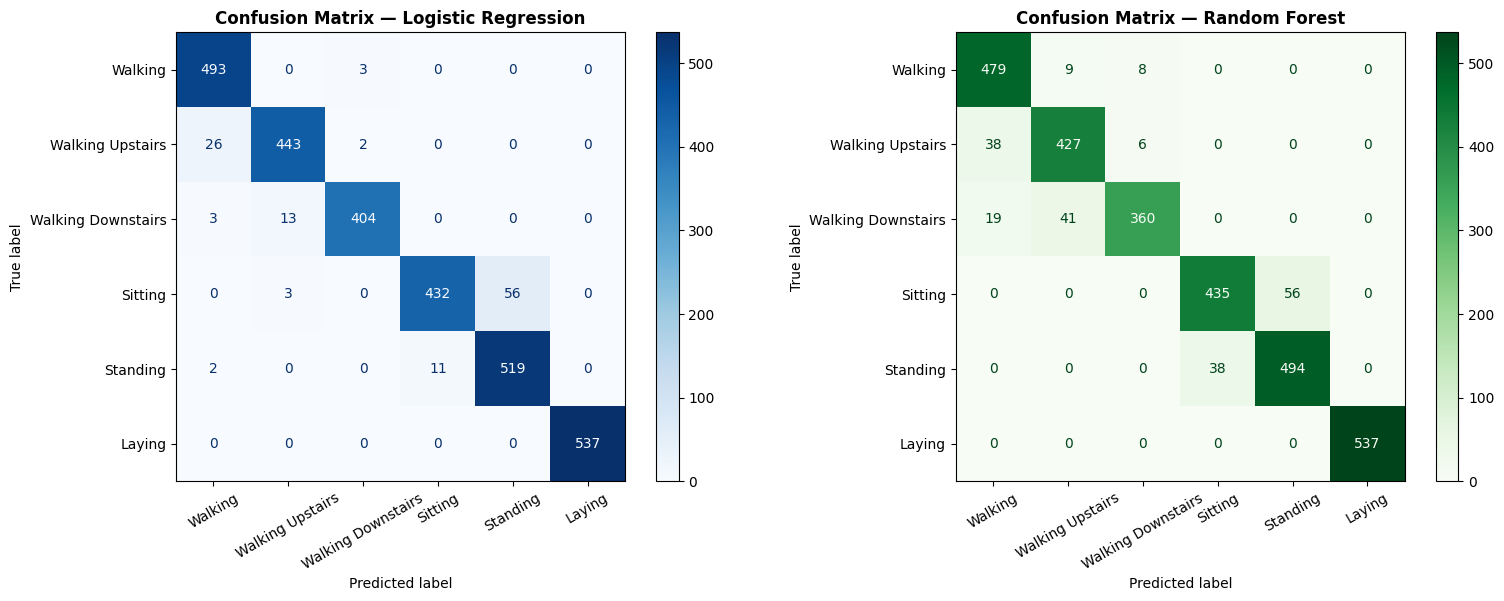

In [10]:
# ── Confusion matrices ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, model, preds, title, cmap in zip(
        axes,
        [lr_model, rf_model],
        [lr_eval['predictions'], rf_eval['predictions']],
        ["Logistic Regression", "Random Forest"],
        ['Blues', 'Greens']):
    cm = confusion_matrix(y_test, preds)
    ConfusionMatrixDisplay(cm, display_labels=list(labels.values())).plot(
        ax=ax, colorbar=True, cmap=cmap, xticks_rotation=30)
    ax.set_title(f"Confusion Matrix — {title}", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


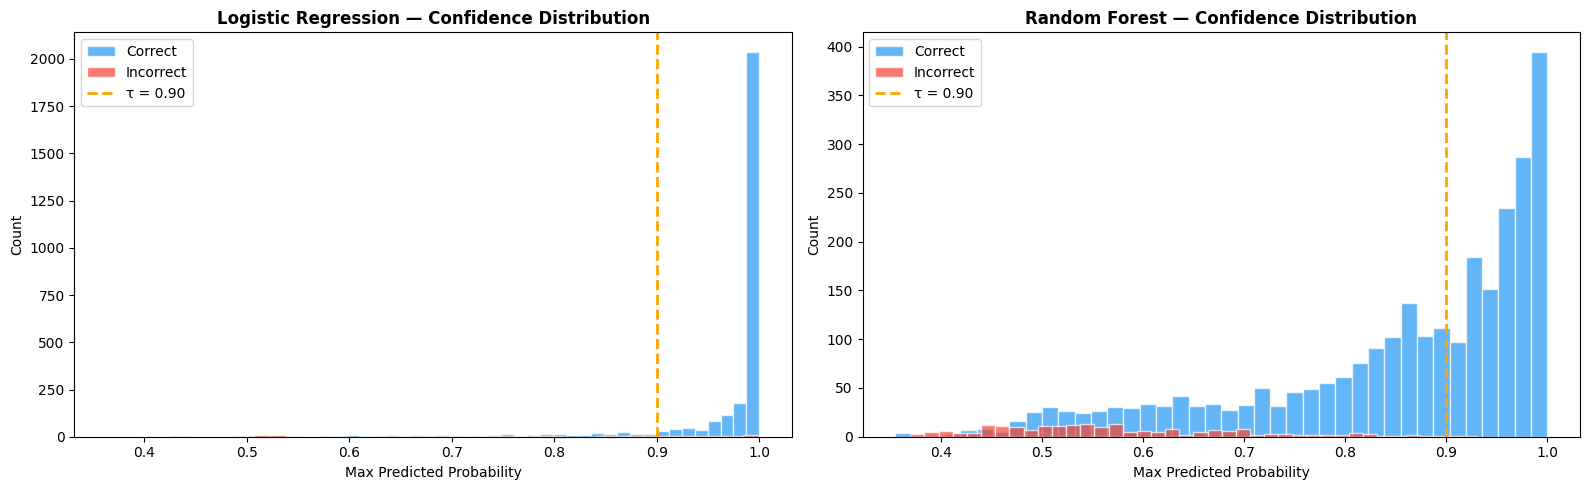


LR  — 32 overconfident wrong predictions (conf > 0.9)
RF  — 2 overconfident wrong predictions (conf > 0.9)
This is the core problem: high confidence does not guarantee correctness.


In [11]:
# ── Confidence distributions ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, ev, name in zip(axes, [lr_eval, rf_eval],
                         ["Logistic Regression", "Random Forest"]):
    conf = ev['confidence']
    correct = ev['correct']
    ax.hist(conf[correct],  bins=40, alpha=0.7, color='#2196F3',
            label='Correct', edgecolor='white')
    ax.hist(conf[~correct], bins=40, alpha=0.7, color='#F44336',
            label='Incorrect', edgecolor='white')
    ax.axvline(x=0.9, color='orange', linestyle='--', linewidth=2, label='τ = 0.90')
    ax.set_title(f"{name} — Confidence Distribution", fontsize=12, fontweight='bold')
    ax.set_xlabel("Max Predicted Probability"); ax.set_ylabel("Count")
    ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f"\nLR  — {overconfident} overconfident wrong predictions (conf > 0.9)")
print(f"RF  — {overconfident_rf} overconfident wrong predictions (conf > 0.9)")
print("This is the core problem: high confidence does not guarantee correctness.")


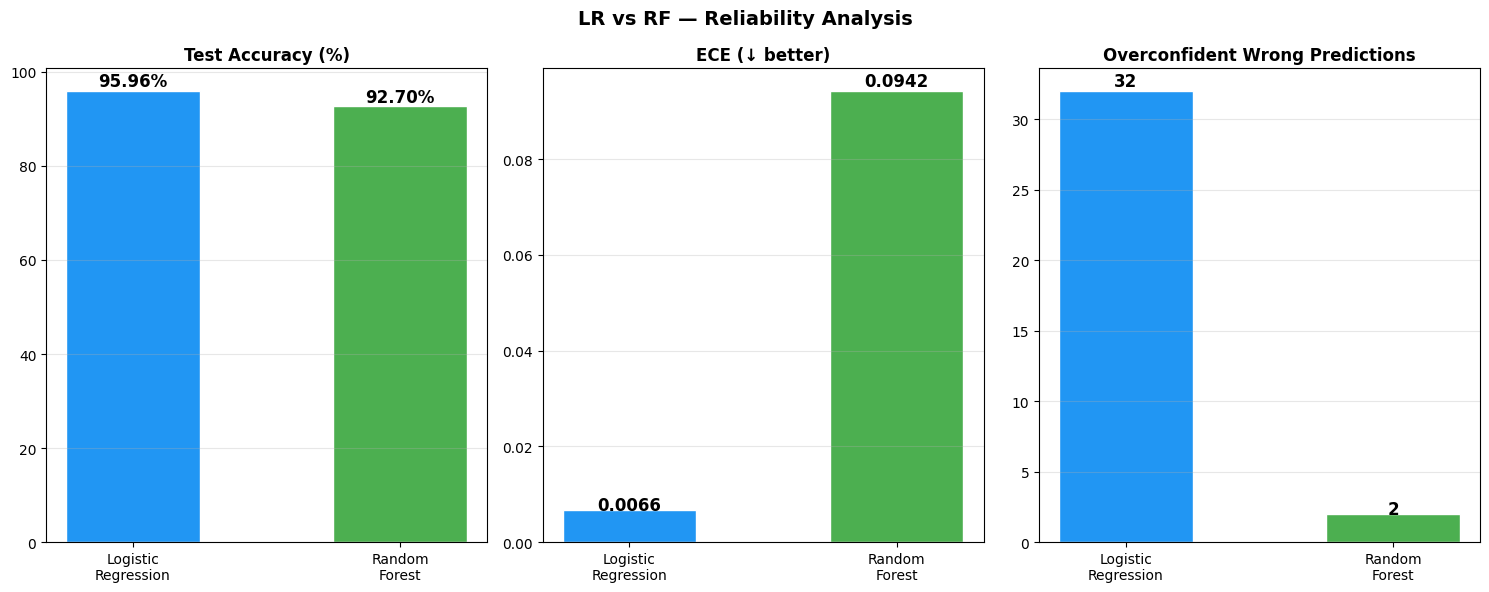

In [12]:
# ── Model comparison bar chart ───────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 6))
models_list = ['Logistic\nRegression', 'Random\nForest']
bar_colors  = ['#2196F3', '#4CAF50']

for ax, vals, title, fmt in zip(
        axes,
        [[accuracy*100, accuracy_rf*100], [ece, ece_rf], [overconfident, overconfident_rf]],
        ["Test Accuracy (%)", "ECE (↓ better)", "Overconfident Wrong Predictions"],
        ["{:.2f}%", "{:.4f}", "{:d}"]):
    bars = ax.bar(models_list, vals, color=bar_colors, edgecolor='white', width=0.5)
    ax.set_title(title, fontsize=12, fontweight='bold')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                fmt.format(val), ha='center', fontweight='bold', fontsize=12)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle("LR vs RF — Reliability Analysis", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 5. Probability Calibration

Fix overconfident predictions using Temperature Scaling, Isotonic Regression, and Platt Scaling. Compare ECE before vs after.

In [13]:
# ── Temperature Scaling ──────────────────────────────────────
class TemperatureScaling:
    """
    Post-hoc calibration: divides logits by learned temperature T.
    T > 1 → softens probabilities (fixes overconfidence)
    T < 1 → sharpens probabilities (fixes underconfidence)
    """
    def __init__(self):
        self.T = 1.0

    def fit(self, logits, y_true_0indexed):
        def nll(T):
            scaled = softmax(logits / T, axis=1)
            scaled = np.clip(scaled, 1e-9, 1.0)
            return -np.sum(np.log(scaled[np.arange(len(y_true_0indexed)),
                                         y_true_0indexed])) / len(y_true_0indexed)
        result = minimize_scalar(nll, bounds=(0.1, 10.0), method='bounded')
        self.T = result.x
        return self

    def calibrate(self, logits):
        return softmax(logits / self.T, axis=1)


# ── Fit all calibration methods ──────────────────────────────
lr_logits_cal  = lr_model.predict_log_proba(X_cal)
lr_logits_eval = lr_model.predict_log_proba(X_eval)

ts_lr = TemperatureScaling()
ts_lr.fit(lr_logits_cal, y_cal.values - 1)

lr_isotonic = CalibratedClassifierCV(lr_model, cv='prefit', method='isotonic')
lr_isotonic.fit(X_cal, y_cal)

lr_sigmoid = CalibratedClassifierCV(lr_model, cv='prefit', method='sigmoid')
lr_sigmoid.fit(X_cal, y_cal)

# ── RF calibration ───────────────────────────────────────────
rf_logits_cal  = rf_model.predict_log_proba(X_cal)
rf_logits_eval = rf_model.predict_log_proba(X_eval)

ts_rf = TemperatureScaling()
ts_rf.fit(rf_logits_cal, y_cal.values - 1)

rf_isotonic = CalibratedClassifierCV(rf_model, cv='prefit', method='isotonic')
rf_isotonic.fit(X_cal, y_cal)

rf_sigmoid = CalibratedClassifierCV(rf_model, cv='prefit', method='sigmoid')
rf_sigmoid.fit(X_cal, y_cal)

print(f"✅ Temperature Scaling fitted")
print(f"   LR T = {ts_lr.T:.4f}  ({'overconfident' if ts_lr.T > 1 else 'underconfident'})")
print(f"   RF T = {ts_rf.T:.4f}  ({'overconfident' if ts_rf.T > 1 else 'underconfident'})")


✅ Temperature Scaling fitted
   LR T = 1.1335  (overconfident)
   RF T = 0.4739  (underconfident)


In [14]:
# ── Compare ECE before/after for LR ─────────────────────────
proba_lr_before = lr_model.predict_proba(X_eval)
proba_lr_ts     = ts_lr.calibrate(lr_logits_eval)
proba_lr_iso    = lr_isotonic.predict_proba(X_eval)
proba_lr_sig    = lr_sigmoid.predict_proba(X_eval)

ece_lr_before = compute_ece(y_eval, proba_lr_before)
ece_lr_ts     = compute_ece(y_eval, proba_lr_ts)
ece_lr_iso    = compute_ece(y_eval, proba_lr_iso)
ece_lr_sig    = compute_ece(y_eval, proba_lr_sig)

# ── Compare ECE before/after for RF ─────────────────────────
proba_rf_before = rf_model.predict_proba(X_eval)
proba_rf_ts     = ts_rf.calibrate(rf_logits_eval)
proba_rf_iso    = rf_isotonic.predict_proba(X_eval)
proba_rf_sig    = rf_sigmoid.predict_proba(X_eval)

ece_rf_before = compute_ece(y_eval, proba_rf_before)
ece_rf_ts     = compute_ece(y_eval, proba_rf_ts)
ece_rf_iso    = compute_ece(y_eval, proba_rf_iso)
ece_rf_sig    = compute_ece(y_eval, proba_rf_sig)

print("=" * 58)
print(f"  {'Method':<25} {'LR ECE':>10}   {'RF ECE':>10}")
print("-" * 58)
for name, lr_e, rf_e in [
    ('Before (raw)',          ece_lr_before, ece_rf_before),
    ('Temperature Scaling',   ece_lr_ts,     ece_rf_ts),
    ('Isotonic Regression',   ece_lr_iso,    ece_rf_iso),
    ('Platt Scaling',         ece_lr_sig,    ece_rf_sig),
]:
    print(f"  {name:<25} {lr_e:>10.4f}   {rf_e:>10.4f}")
print("=" * 58)


  Method                        LR ECE       RF ECE
----------------------------------------------------------
  Before (raw)                  0.0061       0.0925
  Temperature Scaling           0.0103       0.0090
  Isotonic Regression           0.0711       0.0094
  Platt Scaling                 0.1014       0.0184


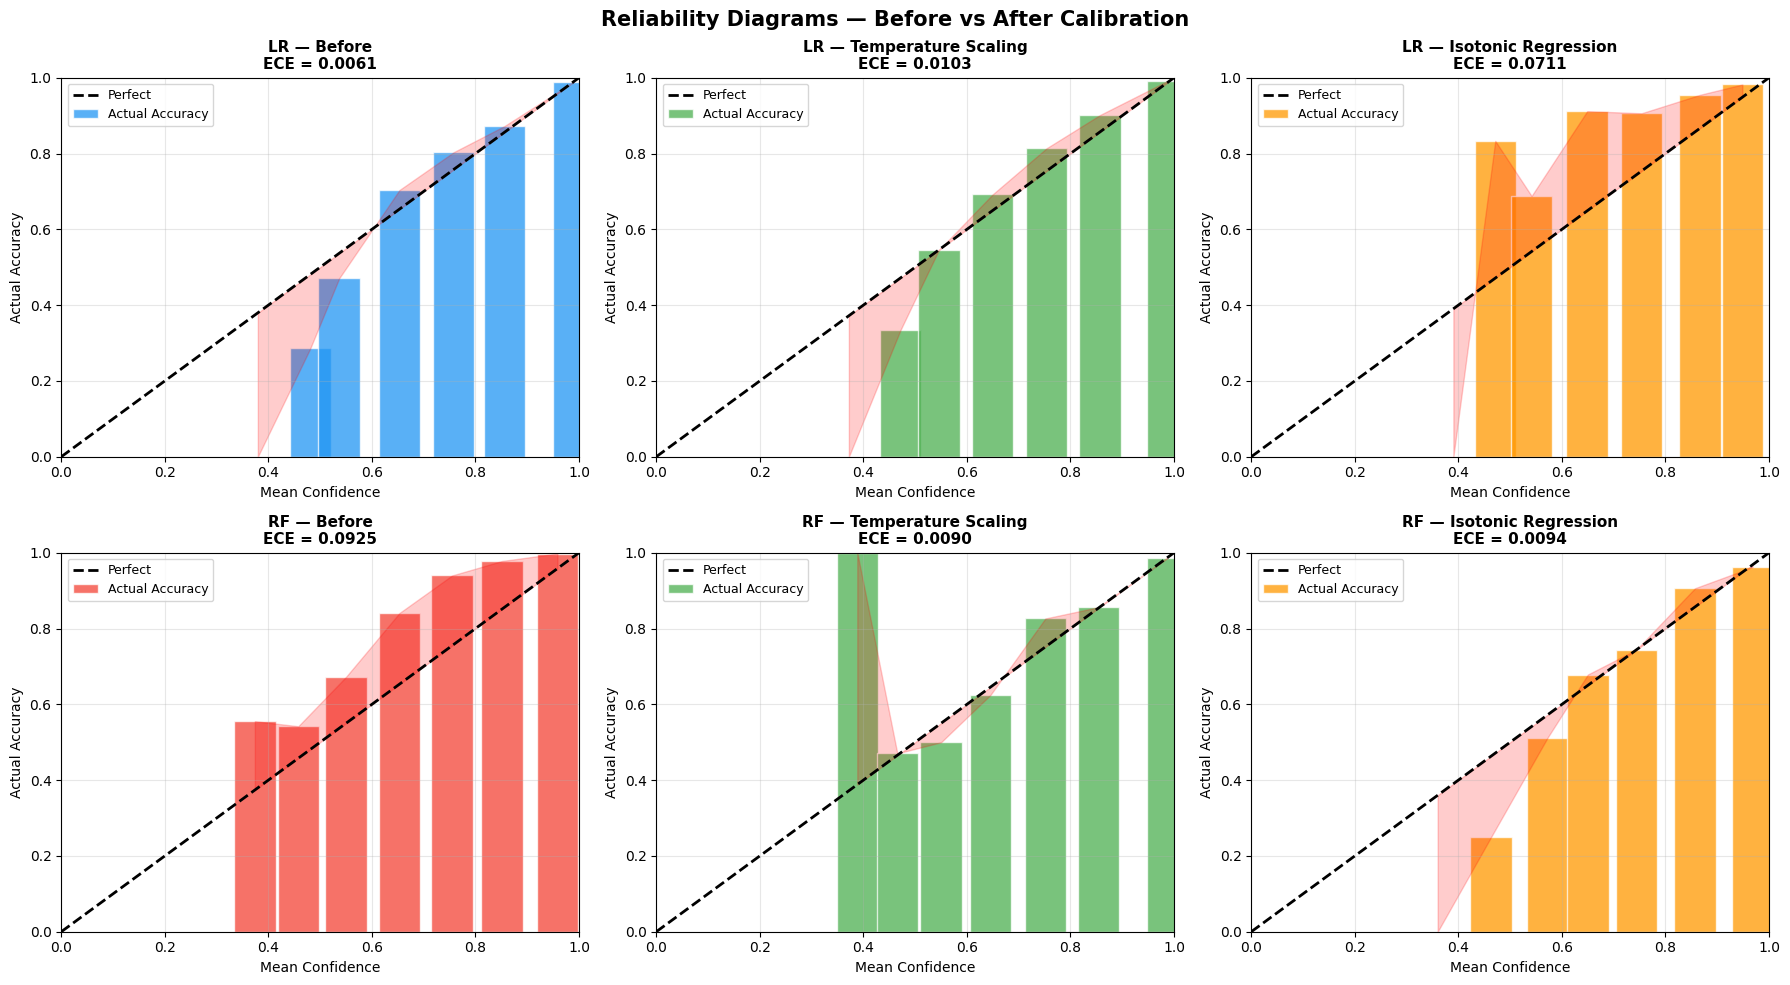

In [15]:
# ── Reliability diagrams — before vs after ───────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Reliability Diagrams — Before vs After Calibration",
             fontsize=15, fontweight='bold')

plot_reliability(axes[0,0], y_eval, proba_lr_before, "LR — Before",              '#2196F3')
plot_reliability(axes[0,1], y_eval, proba_lr_ts,     "LR — Temperature Scaling", '#4CAF50')
plot_reliability(axes[0,2], y_eval, proba_lr_iso,    "LR — Isotonic Regression", '#FF9800')
plot_reliability(axes[1,0], y_eval, proba_rf_before, "RF — Before",              '#F44336')
plot_reliability(axes[1,1], y_eval, proba_rf_ts,     "RF — Temperature Scaling", '#4CAF50')
plot_reliability(axes[1,2], y_eval, proba_rf_iso,    "RF — Isotonic Regression", '#FF9800')

plt.tight_layout()
plt.show()


In [16]:
# ── Select best method and set final calibrated probabilities ─
# LR: already well-calibrated; calibration worsens ECE
# RF: Temperature Scaling gives biggest improvement
lr_results = {'Temperature Scaling': ece_lr_ts,
              'Isotonic Regression': ece_lr_iso,
              'Platt Scaling':       ece_lr_sig}
rf_results = {'Temperature Scaling': ece_rf_ts,
              'Isotonic Regression': ece_rf_iso,
              'Platt Scaling':       ece_rf_sig}

best_lr_method = min(lr_results, key=lr_results.get)
best_rf_method = min(rf_results, key=rf_results.get)

# Final arrays used by all downstream phases
final_lr_proba = lr_model.predict_proba(X_eval)   # raw — already calibrated
final_lr_conf  = np.max(final_lr_proba, axis=1)
final_lr_pred  = lr_model.predict(X_eval)

final_rf_proba = ts_rf.calibrate(rf_model.predict_log_proba(X_eval))
final_rf_conf  = np.max(final_rf_proba, axis=1)
final_rf_pred  = rf_model.predict(X_eval)

print("=" * 60)
print("   CALIBRATION SUMMARY")
print("=" * 60)
print(f"  LR — RAW (best): ECE {ece_lr_before:.4f} (raw)")
print(f"    All calibration methods WORSENED LR ECE:")
print(f"      Temp. Scaling: {ece_lr_ts:.4f}  Isotonic: {ece_lr_iso:.4f}  Platt: {ece_lr_sig:.4f}")
print(f"    → Use raw LR probabilities.")
print()
print(f"  RF — Temperature Scaling (best): ECE {ece_rf_before:.4f} → {ece_rf_ts:.4f}")
print(f"    Improvement: {(ece_rf_before-ece_rf_ts)/ece_rf_before*100:.1f}% reduction in calibration error")
print(f"    → RF was UNDERCONFIDENT (T={ts_rf.T:.4f} < 1); TS sharpened probabilities.")
print()
print("  Design decision for downstream phases:")
print("    LR  → raw probabilities (all calibration methods worsened it)")
print("    RF  → Temperature Scaling probabilities")
print("✅ final_lr_proba, final_rf_proba set for Phase 5+")


   CALIBRATION SUMMARY
  LR — RAW (best): ECE 0.0061 (raw)
    All calibration methods WORSENED LR ECE:
      Temp. Scaling: 0.0103  Isotonic: 0.0711  Platt: 0.1014
    → Use raw LR probabilities.

  RF — Temperature Scaling (best): ECE 0.0925 → 0.0090
    Improvement: 90.3% reduction in calibration error
    → RF was UNDERCONFIDENT (T=0.4739 < 1); TS sharpened probabilities.

  Design decision for downstream phases:
    LR  → raw probabilities (all calibration methods worsened it)
    RF  → Temperature Scaling probabilities
✅ final_lr_proba, final_rf_proba set for Phase 5+


## 6. Selective Prediction Engine

Three-tier system: **ACCEPT** (LR, high confidence) → **DEFER** (XGBoost fallback) → **REJECT** (abstain).

Thresholds τ_high and τ_low are optimised by maximising TPS.

In [17]:
# ── Train XGBoost as the DEFER-tier fallback ─────────────────
print("Training XGBoost fallback model... (~2-3 minutes)")

le = LabelEncoder()
y_train_xgb = le.fit_transform(y_train)   # 1-6 → 0-5
y_eval_xgb  = le.transform(y_eval)
y_cal_xgb   = le.transform(y_cal)

xgb_model = xgb.XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    use_label_encoder=False, eval_metric='mlogloss',
    random_state=42, n_jobs=-1, tree_method='hist'
)
xgb_model.fit(X_train, y_train_xgb)

# Calibrate XGBoost
xgb_isotonic = CalibratedClassifierCV(xgb_model, cv='prefit', method='isotonic')
xgb_isotonic.fit(X_cal, y_cal_xgb)

final_xgb_proba = xgb_isotonic.predict_proba(X_eval)
final_xgb_conf  = np.max(final_xgb_proba, axis=1)
final_xgb_pred  = le.inverse_transform(np.argmax(final_xgb_proba, axis=1))
ece_xgb         = compute_ece(y_eval, final_xgb_proba)

xgb_acc = (le.inverse_transform(xgb_model.predict(X_eval)) == y_eval.values).mean()
print(f"\n✅ XGBoost trained and calibrated")
print(f"   Eval accuracy    : {xgb_acc*100:.2f}%")
print(f"   ECE (calibrated) : {ece_xgb:.4f}")
print()
print("   TPS = Coverage × Selective_Accuracy / (1 + ECE)")


Training XGBoost fallback model... (~2-3 minutes)

✅ XGBoost trained and calibrated
   Eval accuracy    : 94.33%
   ECE (calibrated) : 0.0072

   TPS = Coverage × Selective_Accuracy / (1 + ECE)


In [18]:
# ── Grid search to find optimal tau_high and tau_low ─────────
tau_values  = np.arange(0.50, 1.00, 0.05)
best_tps    = -1
best_tau_high = 0.9
best_tau_low  = 0.5
results_grid  = []

for tau_high in tau_values:
    for tau_low in tau_values:
        if tau_low >= tau_high:
            continue
        res = selective_engine(
            final_lr_conf, final_lr_pred,
            final_xgb_conf, final_xgb_pred,
            y_eval, tau_high, tau_low
        )
        results_grid.append({
            'tau_high': tau_high, 'tau_low': tau_low,
            **{k: res[k] for k in ['coverage','sel_acc','ece_sel','tps',
                                    'n_accept','n_defer','n_reject']}
        })
        if res['tps'] > best_tps:
            best_tps, best_tau_high, best_tau_low = res['tps'], tau_high, tau_low

grid_df = pd.DataFrame(results_grid)
print(f"Grid search complete — {len(results_grid)} threshold combinations tested")
print(f"  Best tau_high : {best_tau_high:.2f}")
print(f"  Best tau_low  : {best_tau_low:.2f}")
print(f"  Best TPS      : {best_tps:.4f}")
print()
print("Top 10 configurations by TPS:")
print(grid_df.nlargest(10, 'tps')[
    ['tau_high','tau_low','coverage','sel_acc','ece_sel','tps']
].to_string(index=False, float_format='%.4f'))


Grid search complete — 45 threshold combinations tested
  Best tau_high : 0.55
  Best tau_low  : 0.50
  Best TPS      : 0.9556

Top 10 configurations by TPS:
 tau_high  tau_low  coverage  sel_acc  ece_sel    tps
   0.5500   0.5000    0.9956   0.9654   0.0058 0.9556
   0.6000   0.5000    0.9956   0.9654   0.0060 0.9555
   0.6500   0.5000    0.9956   0.9649   0.0060 0.9550
   0.7500   0.5000    0.9956   0.9645   0.0057 0.9548
   0.7000   0.5000    0.9956   0.9649   0.0066 0.9544
   0.8000   0.5000    0.9956   0.9596   0.0062 0.9495
   0.6000   0.5500    0.9835   0.9694   0.0048 0.9489
   0.6500   0.5500    0.9835   0.9690   0.0048 0.9484
   0.7000   0.5500    0.9835   0.9690   0.0054 0.9478
   0.7500   0.5500    0.9835   0.9685   0.0050 0.9478


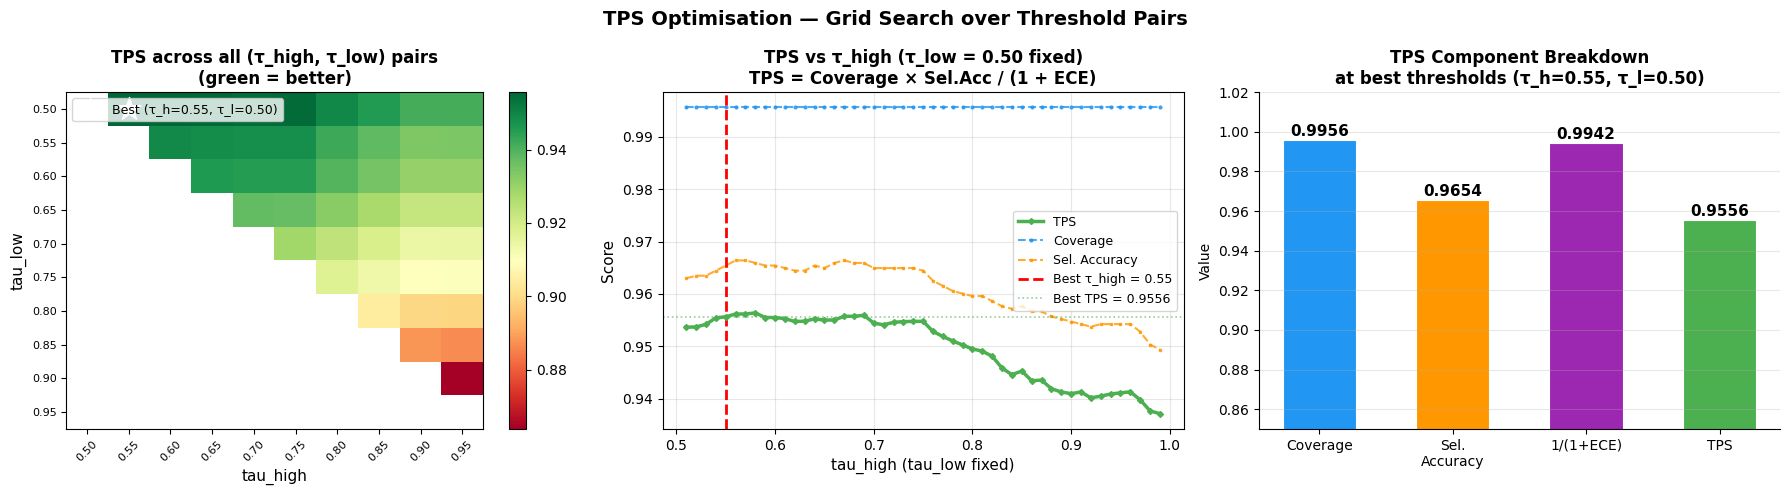

TPS formula: Coverage x Sel.Acc / (1 + ECE)
  = 0.9956 x 0.9654 / (1 + 0.0058)
  = 0.9556


In [20]:
# ── TPS Heatmap + Threshold Sensitivity Plot ─────────────────
# Shows how TPS, Coverage and Selective Accuracy change across
# all (tau_high, tau_low) combinations tested in the grid search.

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("TPS Optimisation — Grid Search over Threshold Pairs",
             fontsize=14, fontweight='bold')

# ── 1. TPS heatmap over tau_high × tau_low ───────────────────
# Build index map from rounded float → integer position.
# np.arange produces values like 0.6000000000000001, so we
# round everything to 2 d.p. before building the lookup dict.
_hi_vals = sorted(set(round(float(r['tau_high']), 2) for r in results_grid))
_lo_vals = sorted(set(round(float(r['tau_low']),  2) for r in results_grid))
_all_vals = sorted(set(_hi_vals) | set(_lo_vals))
n = len(_all_vals)
_idx = {v: k for k, v in enumerate(_all_vals)}   # value → matrix index

tps_matrix = np.full((n, n), np.nan)
cov_matrix = np.full((n, n), np.nan)
acc_matrix = np.full((n, n), np.nan)

for row in results_grid:
    hi = round(float(row['tau_high']), 2)
    lo = round(float(row['tau_low']),  2)
    tps_matrix[_idx[lo], _idx[hi]] = row['tps']
    cov_matrix[_idx[lo], _idx[hi]] = row['coverage']
    acc_matrix[_idx[lo], _idx[hi]] = row['sel_acc']

tick_labels = [f"{v:.2f}" for v in _all_vals]

im0 = axes[0].imshow(tps_matrix, cmap='RdYlGn', aspect='auto',
                      vmin=np.nanmin(tps_matrix), vmax=np.nanmax(tps_matrix))
axes[0].set_xticks(range(n)); axes[0].set_xticklabels(tick_labels, rotation=45, fontsize=8)
axes[0].set_yticks(range(n)); axes[0].set_yticklabels(tick_labels, fontsize=8)
axes[0].set_xlabel("tau_high", fontsize=11); axes[0].set_ylabel("tau_low", fontsize=11)
axes[0].set_title("TPS across all (τ_high, τ_low) pairs\n(green = better)", fontweight='bold')
plt.colorbar(im0, ax=axes[0])

# Mark the best point
_bhi = round(float(best_tau_high), 2)
_blo = round(float(best_tau_low),  2)
axes[0].scatter(_idx[_bhi], _idx[_blo], marker='*', s=300, color='white',
                zorder=5, label=f'Best (τ_h={best_tau_high:.2f}, τ_l={best_tau_low:.2f})')
axes[0].legend(fontsize=9, loc='upper left')

# ── 2. TPS, Coverage, Sel. Accuracy vs tau_high ──────────────
tau_sweep = np.arange(best_tau_low + 0.01, 1.00, 0.01)
tps_line, cov_line, acc_line, tau_line = [], [], [], []

for th in tau_sweep:
    r = selective_engine(final_lr_conf, final_lr_pred,
                         final_xgb_conf, final_xgb_pred,
                         y_eval, th, best_tau_low)
    tps_line.append(r['tps'])
    cov_line.append(r['coverage'])
    acc_line.append(r['sel_acc'])
    tau_line.append(round(float(th), 3))

axes[1].plot(tau_line, tps_line, 'D-', color='#4CAF50', linewidth=2.5,
             markersize=3, label='TPS', zorder=5)
axes[1].plot(tau_line, cov_line, 'o--', color='#2196F3', linewidth=1.5,
             markersize=2, alpha=0.8, label='Coverage')
axes[1].plot(tau_line, acc_line, 's--', color='#FF9800', linewidth=1.5,
             markersize=2, alpha=0.8, label='Sel. Accuracy')
axes[1].axvline(x=best_tau_high, color='red', linestyle='--', linewidth=2,
                label=f'Best τ_high = {best_tau_high:.2f}')
axes[1].axhline(y=best_tps, color='#4CAF50', linestyle=':',
                linewidth=1.2, alpha=0.6, label=f'Best TPS = {best_tps:.4f}')
axes[1].set_xlabel("tau_high (tau_low fixed)", fontsize=11)
axes[1].set_ylabel("Score", fontsize=11)
axes[1].set_title(f"TPS vs τ_high (τ_low = {best_tau_low:.2f} fixed)\n"
                   "TPS = Coverage × Sel.Acc / (1 + ECE)", fontweight='bold')
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)

# ── 3. Component breakdown at best threshold ─────────────────
# Note: best_result is defined in the next cell; use grid_df for values here
_best_row = grid_df[grid_df['tps'] == grid_df['tps'].max()].iloc[0]
components = ['Coverage', 'Sel.\nAccuracy', '1/(1+ECE)', 'TPS']
values = [
    _best_row['coverage'],
    _best_row['sel_acc'],
    1 / (1 + _best_row['ece_sel']),
    _best_row['tps'],
]
bar_colors = ['#2196F3', '#FF9800', '#9C27B0', '#4CAF50']
bars = axes[2].bar(components, values, color=bar_colors,
                   edgecolor='white', linewidth=0.8, width=0.55)
axes[2].set_ylim([0.85, 1.02])
axes[2].set_title(f"TPS Component Breakdown\nat best thresholds "
                   f"(τ_h={best_tau_high:.2f}, τ_l={best_tau_low:.2f})",
                   fontweight='bold')
axes[2].set_ylabel("Value")
for bar, val in zip(bars, values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f'{val:.4f}', ha='center', fontweight='bold', fontsize=11)
axes[2].grid(axis='y', alpha=0.3)
axes[2].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

print(f"TPS formula: Coverage x Sel.Acc / (1 + ECE)")
print(f"  = {_best_row['coverage']:.4f} x {_best_row['sel_acc']:.4f} / (1 + {_best_row['ece_sel']:.4f})")
print(f"  = {_best_row['tps']:.4f}")

In [21]:
# ── Apply best thresholds ────────────────────────────────────
best_result = selective_engine(
    final_lr_conf, final_lr_pred,
    final_xgb_conf, final_xgb_pred,
    y_eval, best_tau_high, best_tau_low
)

decisions  = best_result['decision']
final_pred = best_result['final_pred']
n_total    = len(y_eval)

accept_mask = decisions == 'accept'
defer_mask  = decisions == 'defer'
acc_accept  = (final_pred[accept_mask] == y_eval.values[accept_mask]).mean() if accept_mask.sum() > 0 else 0
acc_defer   = (final_pred[defer_mask]  == y_eval.values[defer_mask]).mean()  if defer_mask.sum()  > 0 else 0
baseline_acc = (final_lr_pred == y_eval.values).mean()

print("=" * 65)
print("   SELECTIVE ENGINE — BEST THRESHOLD RESULTS")
print("=" * 65)
print(f"  tau_high = {best_tau_high:.2f}   tau_low = {best_tau_low:.2f}")
print(f"\n  {'Tier':<8} {'Count':>8} {'%':>8}   {'Accuracy':>10}   Fallback")
print(f"  {'-'*55}")
print(f"  ACCEPT   {best_result['n_accept']:>8} {best_result['n_accept']/n_total*100:>7.1f}%   {acc_accept*100:>9.2f}%   LR direct")
print(f"  DEFER    {best_result['n_defer']:>8} {best_result['n_defer']/n_total*100:>7.1f}%   {acc_defer*100:>9.2f}%   XGBoost")
print(f"  REJECT   {best_result['n_reject']:>8} {best_result['n_reject']/n_total*100:>7.1f}%         —    abstain")
print(f"\n  Overall (covered {best_result['n_accept']+best_result['n_defer']} samples):")
print(f"    Selective Accuracy : {best_result['sel_acc']*100:.2f}%")
print(f"    Coverage           : {best_result['coverage']*100:.1f}%")
print(f"    ECE (selective)    : {best_result['ece_sel']:.4f}")
print(f"    TPS                : {best_result['tps']:.4f}")
print(f"\n  Baseline (always LR, no abstain):")
print(f"    Accuracy : {baseline_acc*100:.2f}%    Coverage : 100%")
print(f"    Accuracy gain on covered samples: +{(best_result['sel_acc']-baseline_acc)*100:.2f}%")


   SELECTIVE ENGINE — BEST THRESHOLD RESULTS
  tau_high = 0.55   tau_low = 0.50

  Tier        Count        %     Accuracy   Fallback
  -------------------------------------------------------
  ACCEPT       2029    98.4%       96.94%   LR direct
  DEFER          25     1.2%       64.00%   XGBoost
  REJECT          9     0.4%         —    abstain

  Overall (covered 2054 samples):
    Selective Accuracy : 96.54%
    Coverage           : 99.6%
    ECE (selective)    : 0.0058
    TPS                : 0.9556

  Baseline (always LR, no abstain):
    Accuracy : 95.88%    Coverage : 100%
    Accuracy gain on covered samples: +0.66%


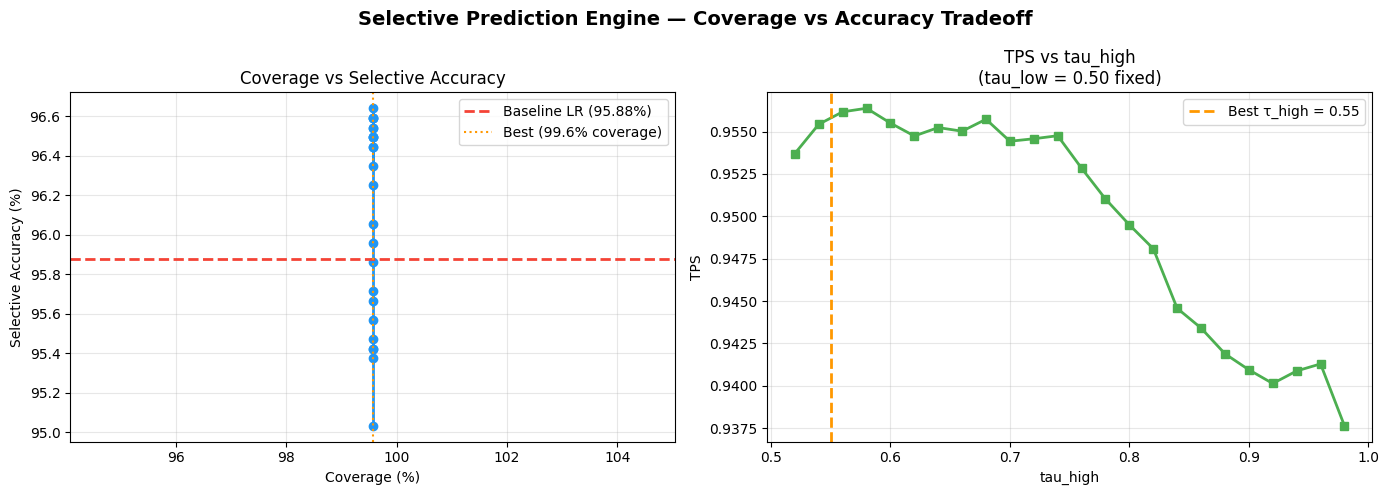

In [22]:
# ── Coverage vs Selective Accuracy tradeoff plot ─────────────
tau_sweep  = np.arange(0.50, 1.00, 0.02)
coverages, sel_accs, tps_vals, tau_used = [], [], [], []

for tau_high in tau_sweep:
    if best_tau_low >= tau_high:
        continue
    r = selective_engine(final_lr_conf, final_lr_pred,
                         final_xgb_conf, final_xgb_pred,
                         y_eval, tau_high, best_tau_low)
    coverages.append(r['coverage'] * 100)
    sel_accs.append(r['sel_acc'] * 100)
    tps_vals.append(r['tps'])
    tau_used.append(tau_high)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Selective Prediction Engine — Coverage vs Accuracy Tradeoff",
             fontsize=14, fontweight='bold')

axes[0].plot(coverages, sel_accs, 'o-', color='#2196F3', linewidth=2, markersize=6)
axes[0].axhline(y=baseline_acc*100, color='#F44336', linestyle='--',
                linewidth=2, label=f'Baseline LR ({baseline_acc*100:.2f}%)')
axes[0].axvline(x=best_result['coverage']*100, color='#FF9800', linestyle=':',
                linewidth=1.5, label=f'Best ({best_result["coverage"]*100:.1f}% coverage)')
axes[0].set_xlabel("Coverage (%)"); axes[0].set_ylabel("Selective Accuracy (%)")
axes[0].set_title("Coverage vs Selective Accuracy"); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(tau_used, tps_vals, 's-', color='#4CAF50', linewidth=2, markersize=6)
axes[1].axvline(x=best_tau_high, color='#FF9800', linestyle='--',
                linewidth=2, label=f'Best τ_high = {best_tau_high:.2f}')
axes[1].set_xlabel("tau_high"); axes[1].set_ylabel("TPS")
axes[1].set_title(f"TPS vs tau_high\n(tau_low = {best_tau_low:.2f} fixed)")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 7. Noise Injection Experiments

Simulate degraded sensor conditions by adding Gaussian noise σ ∈ {0.0, 0.05, 0.10, 0.20, 0.50}.
Pipeline: LR → XGBoost (defer) → REJECT.

In [23]:
noise_levels  = [0.0, 0.05, 0.10, 0.20, 0.50]
noise_results = []

for sigma in noise_levels:
    np.random.seed(42)
    X_noisy = X_eval + np.random.normal(0, sigma, X_eval.shape) if sigma > 0 else X_eval.copy()

    # LR on noisy data
    proba_noisy = lr_model.predict_proba(X_noisy)
    pred_noisy  = lr_model.predict(X_noisy)
    conf_noisy  = np.max(proba_noisy, axis=1)
    correct_n   = (pred_noisy == y_eval.values)

    # XGBoost on noisy data
    xgb_proba_n = xgb_isotonic.predict_proba(X_noisy)
    xgb_conf_n  = np.max(xgb_proba_n, axis=1)
    xgb_pred_n  = le.inverse_transform(np.argmax(xgb_proba_n, axis=1))

    acc_n  = correct_n.mean()
    ece_n  = compute_ece(y_eval, proba_noisy)
    tps_n  = compute_tps(1.0, acc_n, ece_n)      # TPS at full coverage (no abstain)
    overconf = np.sum((conf_noisy > 0.9) & ~correct_n)

    eng = selective_engine(conf_noisy, pred_noisy,
                           xgb_conf_n, xgb_pred_n,
                           y_eval, best_tau_high, best_tau_low)

    noise_results.append({
        'sigma': sigma, 'accuracy': acc_n, 'ece': ece_n,
        'mean_conf': conf_noisy.mean(), 'overconf_err': overconf,
        'n_accept': eng['n_accept'], 'n_defer': eng['n_defer'],
        'n_reject': eng['n_reject'],
        'coverage': eng['coverage'], 'sel_acc': eng['sel_acc'],
        'ece_sel': eng['ece_sel'], 'tps': eng['tps'],
    })

noise_df = pd.DataFrame(noise_results)
print("✅ Noise injection complete\n")

print(f"  {'σ':<6} {'Accuracy':>10} {'ECE':>8} {'Mean Conf':>10} {'Overconf':>10} "
      f"{'Reject':>8} {'Coverage':>10} {'Sel Acc':>10} {'TPS':>8}")
print("  " + "-" * 82)
for _, r in noise_df.iterrows():
    flag = " ← clean" if r['sigma'] == 0.0 else ""
    print(f"  {r['sigma']:<6.2f} {r['accuracy']*100:>9.2f}% {r['ece']:>8.4f} "
          f"{r['mean_conf']:>10.3f} {r['overconf_err']:>10.0f} "
          f"{r['n_reject']:>8.0f} {r['coverage']*100:>9.1f}% "
          f"{r['sel_acc']*100:>9.2f}% {r['tps']:>8.4f}{flag}")


✅ Noise injection complete

  σ        Accuracy      ECE  Mean Conf   Overconf   Reject   Coverage    Sel Acc      TPS
  ----------------------------------------------------------------------------------
  0.00       95.88%   0.0061      0.958         20        9      99.6%     96.54%   0.9556 ← clean
  0.05       96.17%   0.0084      0.956         20        5      99.8%     96.40%   0.9553
  0.10       94.86%   0.0072      0.953         21        6      99.7%     94.94%   0.9386
  0.20       91.95%   0.0280      0.946         59       17      99.2%     92.42%   0.8894
  0.50       78.28%   0.1458      0.929        225       18      99.1%     79.12%   0.6858


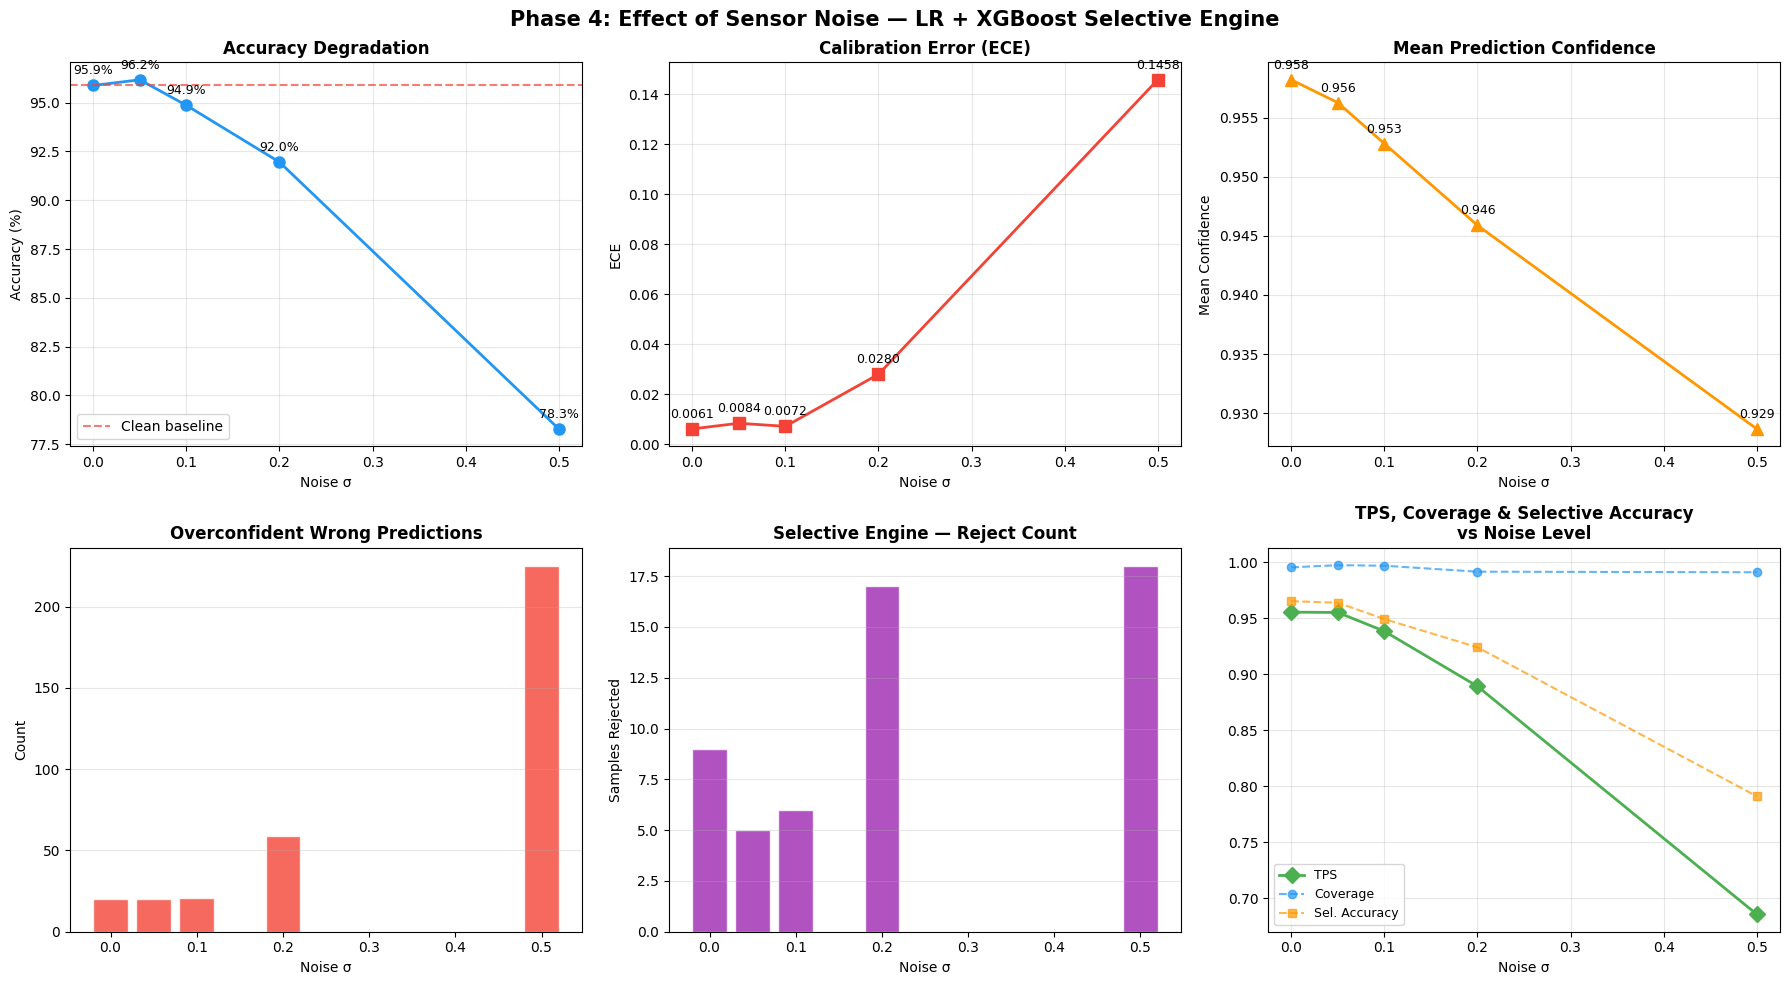

In [24]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Phase 4: Effect of Sensor Noise — LR + XGBoost Selective Engine",
             fontsize=15, fontweight='bold')

sigmas = noise_df['sigma'].values
blue, red, amber, green, purple = '#2196F3','#F44336','#FF9800','#4CAF50','#9C27B0'

def annotate(ax, xs, ys, fmt='{:.1f}%'):
    for x, y in zip(xs, ys):
        ax.annotate(fmt.format(y), (x, y), textcoords="offset points",
                    xytext=(0, 8), ha='center', fontsize=9)

axes[0,0].plot(sigmas, noise_df['accuracy']*100, 'o-', color=blue, linewidth=2, markersize=8)
axes[0,0].axhline(noise_df.iloc[0]['accuracy']*100, color=red, linestyle='--', linewidth=1.5, alpha=0.7, label='Clean baseline')
axes[0,0].set(xlabel="Noise σ", ylabel="Accuracy (%)"); axes[0,0].set_title("Accuracy Degradation", fontweight='bold')
axes[0,0].legend(); axes[0,0].grid(True, alpha=0.3)
annotate(axes[0,0], sigmas, noise_df['accuracy']*100)

axes[0,1].plot(sigmas, noise_df['ece'], 's-', color=red, linewidth=2, markersize=8)
axes[0,1].set(xlabel="Noise σ", ylabel="ECE"); axes[0,1].set_title("Calibration Error (ECE)", fontweight='bold')
axes[0,1].grid(True, alpha=0.3)
annotate(axes[0,1], sigmas, noise_df['ece'], '{:.4f}')

axes[0,2].plot(sigmas, noise_df['mean_conf'], '^-', color=amber, linewidth=2, markersize=8)
axes[0,2].set(xlabel="Noise σ", ylabel="Mean Confidence"); axes[0,2].set_title("Mean Prediction Confidence", fontweight='bold')
axes[0,2].grid(True, alpha=0.3)
annotate(axes[0,2], sigmas, noise_df['mean_conf'], '{:.3f}')

axes[1,0].bar(sigmas, noise_df['overconf_err'], color=red, alpha=0.8, width=0.04, edgecolor='white')
axes[1,0].set(xlabel="Noise σ", ylabel="Count"); axes[1,0].set_title("Overconfident Wrong Predictions", fontweight='bold')
axes[1,0].grid(True, alpha=0.3, axis='y')

axes[1,1].bar(sigmas, noise_df['n_reject'], color=purple, alpha=0.8, width=0.04, edgecolor='white')
axes[1,1].set(xlabel="Noise σ", ylabel="Samples Rejected"); axes[1,1].set_title("Selective Engine — Reject Count", fontweight='bold')
axes[1,1].grid(True, alpha=0.3, axis='y')

# TPS across noise levels — new plot showing all three components
axes[1,2].plot(sigmas, noise_df['tps'], 'D-', color=green, linewidth=2, markersize=8, label='TPS')
axes[1,2].plot(sigmas, noise_df['coverage'], 'o--', color=blue, linewidth=1.5, markersize=6, alpha=0.7, label='Coverage')
axes[1,2].plot(sigmas, noise_df['sel_acc'], 's--', color=amber, linewidth=1.5, markersize=6, alpha=0.7, label='Sel. Accuracy')
axes[1,2].set(xlabel="Noise σ"); axes[1,2].set_title("TPS, Coverage & Selective Accuracy\nvs Noise Level", fontweight='bold')
axes[1,2].legend(fontsize=9); axes[1,2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [25]:
clean = noise_df.iloc[0]
worst = noise_df.iloc[-1]

print("=" * 65)
print("   PHASE 4 SUMMARY — NOISE INJECTION")
print("=" * 65)
print(f"""
  Pipeline: LR → XGBoost (DEFER) → REJECT
  Thresholds: tau_high={best_tau_high:.2f}, tau_low={best_tau_low:.2f}

  Clean (σ=0.00):
    Accuracy     : {clean['accuracy']*100:.2f}%
    ECE          : {clean['ece']:.4f}
    Mean conf    : {clean['mean_conf']:.3f}
    Overconf err : {int(clean['overconf_err'])}
    TPS          : {clean['tps']:.4f}

  Worst noise (σ=0.50):
    Accuracy     : {worst['accuracy']*100:.2f}%   ({(clean['accuracy']-worst['accuracy'])*100:+.2f}% drop)
    ECE          : {worst['ece']:.4f}   ({worst['ece']-clean['ece']:+.4f} rise)
    Mean conf    : {worst['mean_conf']:.3f}   ({clean['mean_conf']-worst['mean_conf']:+.3f} drop)
    Overconf err : {int(worst['overconf_err'])}
    TPS          : {worst['tps']:.4f}

  Critical finding — ENGINE LIMITATION UNDER HEAVY NOISE:
    At σ=0.50, accuracy dropped {(clean['accuracy']-worst['accuracy'])*100:.1f}%
    but mean confidence only dropped {(clean['mean_conf']-worst['mean_conf']):.3f}.
    LR remains overconfident under Gaussian noise.
    → Motivates Phase 5: drift detection must catch distribution
      shift at the INPUT level before predictions are made.

  Anomaly — σ=0.05 accuracy ({noise_df.iloc[1]['accuracy']*100:.2f}%) > clean ({clean['accuracy']*100:.2f}%):
    Small Gaussian noise (σ=0.05) can act as a regulariser on this
    test split — slightly smoothing decision boundaries. This effect
    disappears at σ=0.10 where accuracy drops normally.
    Not a data quality issue; a known empirical curiosity.
""")


   PHASE 4 SUMMARY — NOISE INJECTION

  Pipeline: LR → XGBoost (DEFER) → REJECT
  Thresholds: tau_high=0.55, tau_low=0.50

  Clean (σ=0.00):
    Accuracy     : 95.88%
    ECE          : 0.0061
    Mean conf    : 0.958
    Overconf err : 20
    TPS          : 0.9556

  Worst noise (σ=0.50):
    Accuracy     : 78.28%   (+17.60% drop)
    ECE          : 0.1458   (+0.1397 rise)
    Mean conf    : 0.929   (+0.030 drop)
    Overconf err : 225
    TPS          : 0.6858

  Critical finding — ENGINE LIMITATION UNDER HEAVY NOISE:
    At σ=0.50, accuracy dropped 17.6%
    but mean confidence only dropped 0.030.
    LR remains overconfident under Gaussian noise.
    → Motivates Phase 5: drift detection must catch distribution
      shift at the INPUT level before predictions are made.

  Anomaly — σ=0.05 accuracy (96.17%) > clean (95.88%):
    Small Gaussian noise (σ=0.05) can act as a regulariser on this
    test split — slightly smoothing decision boundaries. This effect
    disappears at σ=0.10

## 8. Drift Detection

KS-test (statistic threshold, not p-value) + PSI (Z-score normalised, sqrt smoothing).

Adaptive threshold logic: STABLE (PSI < 0.10) → MONITOR (0.10–0.25) → DRIFT DETECTED (> 0.25).

In [26]:
drift_results = []

for sigma in noise_levels:
    np.random.seed(42)
    X_noisy = X_eval + np.random.normal(0, sigma, X_eval.shape) if sigma > 0 else X_eval.copy()
    X_noisy_df = pd.DataFrame(X_noisy, columns=X_eval.columns)

    ks  = ks_drift(X_train, X_noisy_df, ks_threshold=0.10)
    psi = psi_score(X_train, X_noisy_df)

    drift_results.append({
        'sigma': sigma,
        'ks_drift_frac'   : ks['drift_fraction'],
        'n_drifted_feats' : ks['n_drifted'],
        'mean_ks_stat'    : ks['mean_ks_stat'],
        'max_ks_stat'     : ks['max_ks_stat'],
        'mean_psi'        : psi['mean_psi'],
        'max_psi'         : psi['max_psi'],
        'verdict'         : psi['verdict'],
        '_ks_obj'         : ks,
        '_psi_obj'        : psi,
    })
    print(f"  σ={sigma:.2f} | KS drifted={ks['n_drifted']}/{X_train.shape[1]} "
          f"({ks['drift_fraction']*100:.1f}%) | mean KS={ks['mean_ks_stat']:.4f} | "
          f"mean PSI={psi['mean_psi']:.4f} | {psi['verdict']}")

drift_df = pd.DataFrame([{k:v for k,v in r.items() if not k.startswith('_')}
                          for r in drift_results])
print("\n✅ Drift detection complete")


  σ=0.00 | KS drifted=4/561 (0.7%) | mean KS=0.0563 | mean PSI=0.0220 | STABLE
  σ=0.05 | KS drifted=384/561 (68.4%) | mean KS=0.1730 | mean PSI=0.2115 | MONITOR
  σ=0.10 | KS drifted=390/561 (69.5%) | mean KS=0.2007 | mean PSI=0.2457 | MONITOR
  σ=0.20 | KS drifted=436/561 (77.7%) | mean KS=0.2388 | mean PSI=0.3352 | DRIFT DETECTED
  σ=0.50 | KS drifted=558/561 (99.5%) | mean KS=0.3177 | mean PSI=0.4973 | DRIFT DETECTED

✅ Drift detection complete


In [27]:
# ── Drift detection results table ────────────────────────────
print("\n" + "=" * 90)
print("   DRIFT DETECTION RESULTS TABLE")
print("=" * 90)
print(f"  {'σ':<6} {'KS Drifted':>12} {'% Features':>12} {'Mean KS':>10} "
      f"{'Mean PSI':>10} {'Max PSI':>10} {'Verdict':>16}")
print("  " + "-" * 85)

for _, r in drift_df.iterrows():
    flag = " ← baseline" if r['sigma'] == 0.0 else ""
    print(f"  {r['sigma']:<6.2f} {int(r['n_drifted_feats']):>12} "
          f"{r['ks_drift_frac']*100:>11.1f}% "
          f"{r['mean_ks_stat']:>10.4f} "
          f"{r['mean_psi']:>10.4f} "
          f"{r['max_psi']:>10.4f} "
          f"{r['verdict']:>16}{flag}")
print("=" * 90)

# Adaptive threshold summary
first_monitor = next((r['sigma'] for r in drift_results
                       if r['verdict'] in ('MONITOR','DRIFT DETECTED')), None)
first_drift   = next((r['sigma'] for r in drift_results
                       if r['verdict'] == 'DRIFT DETECTED'), None)

print(f"""
  Adaptive threshold logic (PSI-based):
    STABLE          PSI < 0.10  → serve normally
    MONITOR         PSI 0.10–0.25 → trigger alert, increase monitoring
    DRIFT DETECTED  PSI > 0.25  → halt deployment, retrain

  First MONITOR at σ = {first_monitor}
  First DRIFT    at σ = {first_drift}

  Key safety finding:
    At σ=0.05, drift is detectable (PSI > 0.10) but selective
    engine still accepts 99.8% of predictions. Drift detection
    provides an EARLY WARNING the engine cannot give alone.
""")



   DRIFT DETECTION RESULTS TABLE
  σ        KS Drifted   % Features    Mean KS   Mean PSI    Max PSI          Verdict
  -------------------------------------------------------------------------------------
  0.00              4         0.7%     0.0563     0.0220     0.0836           STABLE ← baseline
  0.05            384        68.4%     0.1730     0.2115     0.5000          MONITOR
  0.10            390        69.5%     0.2007     0.2457     0.5000          MONITOR
  0.20            436        77.7%     0.2388     0.3352     0.5000   DRIFT DETECTED
  0.50            558        99.5%     0.3177     0.4973     0.5000   DRIFT DETECTED

  Adaptive threshold logic (PSI-based):
    STABLE          PSI < 0.10  → serve normally
    MONITOR         PSI 0.10–0.25 → trigger alert, increase monitoring
    DRIFT DETECTED  PSI > 0.25  → halt deployment, retrain

  First MONITOR at σ = 0.05
  First DRIFT    at σ = 0.2

  Key safety finding:
    At σ=0.05, drift is detectable (PSI > 0.10) but selec

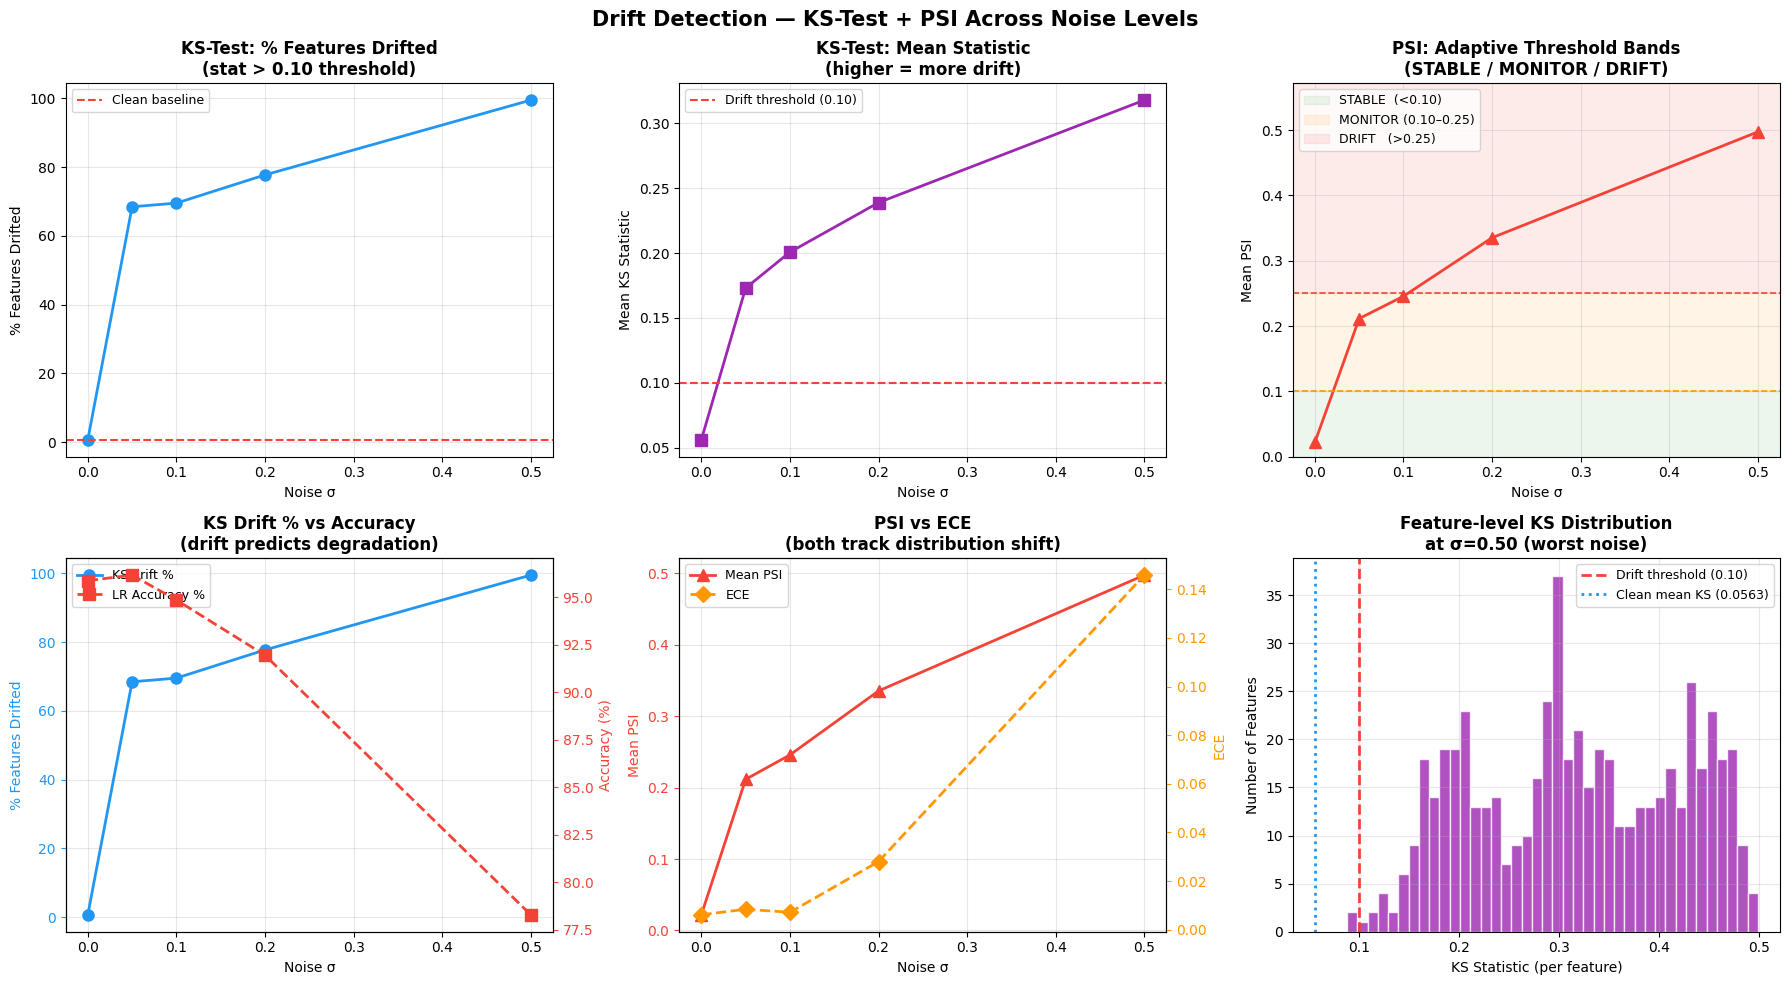

In [28]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Drift Detection — KS-Test + PSI Across Noise Levels",
             fontsize=15, fontweight='bold')

sigmas     = drift_df['sigma'].values
blue, red  = '#2196F3', '#F44336'
amber, grn = '#FF9800', '#4CAF50'
purple     = '#9C27B0'

# 1. KS drifted fraction
axes[0,0].plot(sigmas, drift_df['ks_drift_frac']*100, 'o-', color=blue, linewidth=2, markersize=8)
axes[0,0].axhline(drift_df.iloc[0]['ks_drift_frac']*100, color=red, linestyle='--',
                   linewidth=1.5, label=f"Clean baseline")
axes[0,0].set(xlabel="Noise σ", ylabel="% Features Drifted")
axes[0,0].set_title("KS-Test: % Features Drifted\n(stat > 0.10 threshold)", fontweight='bold')
axes[0,0].legend(fontsize=9); axes[0,0].grid(True, alpha=0.3)

# 2. Mean KS statistic
axes[0,1].plot(sigmas, drift_df['mean_ks_stat'], 's-', color=purple, linewidth=2, markersize=8)
axes[0,1].axhline(0.10, color=red, linestyle='--', linewidth=1.5, label='Drift threshold (0.10)')
axes[0,1].set(xlabel="Noise σ", ylabel="Mean KS Statistic")
axes[0,1].set_title("KS-Test: Mean Statistic\n(higher = more drift)", fontweight='bold')
axes[0,1].legend(fontsize=9); axes[0,1].grid(True, alpha=0.3)

# 3. PSI with adaptive threshold bands
max_psi = max(drift_df['mean_psi'].max() * 1.15, 0.35)
axes[0,2].plot(sigmas, drift_df['mean_psi'], '^-', color=red, linewidth=2, markersize=8)
axes[0,2].axhspan(0,    0.10, alpha=0.10, color=grn,   label='STABLE  (<0.10)')
axes[0,2].axhspan(0.10, 0.25, alpha=0.10, color=amber, label='MONITOR (0.10–0.25)')
axes[0,2].axhspan(0.25, max_psi, alpha=0.10, color=red, label='DRIFT   (>0.25)')
axes[0,2].axhline(0.10, color=amber, linestyle='--', linewidth=1.2)
axes[0,2].axhline(0.25, color=red,   linestyle='--', linewidth=1.2)
axes[0,2].set_ylim([0, max_psi])
axes[0,2].set(xlabel="Noise σ", ylabel="Mean PSI")
axes[0,2].set_title("PSI: Adaptive Threshold Bands\n(STABLE / MONITOR / DRIFT)", fontweight='bold')
axes[0,2].legend(fontsize=9, loc='upper left'); axes[0,2].grid(True, alpha=0.3)

# 4. KS drift % vs Accuracy (dual axis)
ax4 = axes[1,0]; ax4t = ax4.twinx()
ax4.plot(sigmas,  drift_df['ks_drift_frac']*100, 'o-', color=blue, linewidth=2, markersize=8, label='KS drift %')
ax4t.plot(sigmas, noise_df['accuracy']*100, 's--', color=red, linewidth=2, markersize=8, label='LR Accuracy %')
ax4.set_xlabel("Noise σ"); ax4.set_ylabel("% Features Drifted", color=blue)
ax4t.set_ylabel("Accuracy (%)", color=red)
ax4.set_title("KS Drift % vs Accuracy\n(drift predicts degradation)", fontweight='bold')
ax4.tick_params(axis='y', colors=blue); ax4t.tick_params(axis='y', colors=red)
lines = ax4.get_legend_handles_labels()[0] + ax4t.get_legend_handles_labels()[0]
labs  = ax4.get_legend_handles_labels()[1] + ax4t.get_legend_handles_labels()[1]
ax4.legend(lines, labs, fontsize=9); ax4.grid(True, alpha=0.3)

# 5. PSI vs ECE
ax5 = axes[1,1]; ax5t = ax5.twinx()
ax5.plot(sigmas,  drift_df['mean_psi'], '^-', color=red, linewidth=2, markersize=8, label='Mean PSI')
ax5t.plot(sigmas, noise_df['ece'], 'D--', color=amber, linewidth=2, markersize=8, label='ECE')
ax5.set_xlabel("Noise σ"); ax5.set_ylabel("Mean PSI", color=red)
ax5t.set_ylabel("ECE", color=amber)
ax5.set_title("PSI vs ECE\n(both track distribution shift)", fontweight='bold')
ax5.tick_params(axis='y', colors=red); ax5t.tick_params(axis='y', colors=amber)
lines = ax5.get_legend_handles_labels()[0] + ax5t.get_legend_handles_labels()[0]
labs  = ax5.get_legend_handles_labels()[1] + ax5t.get_legend_handles_labels()[1]
ax5.legend(lines, labs, fontsize=9); ax5.grid(True, alpha=0.3)

# 6. Feature-level KS distribution at σ=0.5
ks_worst = drift_results[-1]['_ks_obj']['ks_stats']
axes[1,2].hist(ks_worst, bins=40, color=purple, alpha=0.8, edgecolor='white')
axes[1,2].axvline(0.10, color=red, linestyle='--', linewidth=2, label='Drift threshold (0.10)')
axes[1,2].axvline(drift_df.iloc[0]['mean_ks_stat'], color=blue, linestyle=':', linewidth=2,
                   label=f"Clean mean KS ({drift_df.iloc[0]['mean_ks_stat']:.4f})")
axes[1,2].set(xlabel="KS Statistic (per feature)", ylabel="Number of Features")
axes[1,2].set_title("Feature-level KS Distribution\nat σ=0.50 (worst noise)", fontweight='bold')
axes[1,2].legend(fontsize=9); axes[1,2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 9. SHAP Explainability

TreeExplainer on RF and XGBoost. Questions answered:
1. Which features matter most globally?
2. How does each feature push predictions?
3. Do DEFERRED samples have different patterns?
4. Which features drove a specific wrong prediction?

In [29]:
shap.initjs()

np.random.seed(42)
shap_idx    = np.random.choice(len(X_eval), size=500, replace=False)
X_shap      = X_eval.iloc[shap_idx].reset_index(drop=True)
y_shap_true = y_eval.iloc[shap_idx].reset_index(drop=True)
decisions_shap = best_result['decision'][shap_idx]

print(f"SHAP subsample (n=500):")
print(f"  ACCEPT : {(decisions_shap=='accept').sum()}")
print(f"  DEFER  : {(decisions_shap=='defer').sum()}")
print(f"  REJECT : {(decisions_shap=='reject').sum()}")


SHAP subsample (n=500):
  ACCEPT : 496
  DEFER  : 2
  REJECT : 2


In [30]:
print("Computing RF SHAP values... (~60s)")
explainer_rf   = shap.TreeExplainer(rf_model)
shap_values_rf = explainer_rf.shap_values(X_shap)
# shape: (500, 561, 6) — samples × features × classes

rf_shap_mean_abs      = np.mean(np.abs(shap_values_rf), axis=2)  # (500, 561)
rf_feature_importance = rf_shap_mean_abs.mean(axis=0)             # (561,)
top20_rf_idx          = np.argsort(rf_feature_importance)[::-1][:20]
print(f"✅ RF SHAP: shape={shap_values_rf.shape}")
print(f"   Top 5: {[f'F{i}' for i in top20_rf_idx[:5]]}")

print("\nComputing XGBoost SHAP values... (~30s)")
explainer_xgb   = shap.TreeExplainer(xgb_model)
shap_values_xgb = explainer_xgb.shap_values(X_shap)
# shape: (500, 561, 6)

xgb_shap_mean_abs      = np.mean(np.abs(shap_values_xgb), axis=2)
xgb_feature_importance = xgb_shap_mean_abs.mean(axis=0)
top20_xgb_idx          = np.argsort(xgb_feature_importance)[::-1][:20]
print(f"✅ XGBoost SHAP: shape={shap_values_xgb.shape}")
print(f"   Top 5: {[f'F{i}' for i in top20_xgb_idx[:5]]}")

overlap = set(top20_rf_idx[:10].tolist()) & set(top20_xgb_idx[:10].tolist())
print(f"\nTop-10 overlap (RF ∩ XGBoost): {len(overlap)}/10 features shared")
print(f"  Shared: {sorted(overlap)}")


Computing RF SHAP values... (~60s)
✅ RF SHAP: shape=(500, 561, 6)
   Top 5: ['F40', 'F52', 'F558', 'F56', 'F41']

Computing XGBoost SHAP values... (~30s)
✅ XGBoost SHAP: shape=(500, 561, 6)
   Top 5: ['F52', 'F9', 'F40', 'F302', 'F53']

Top-10 overlap (RF ∩ XGBoost): 4/10 features shared
  Shared: [40, 41, 52, 53]


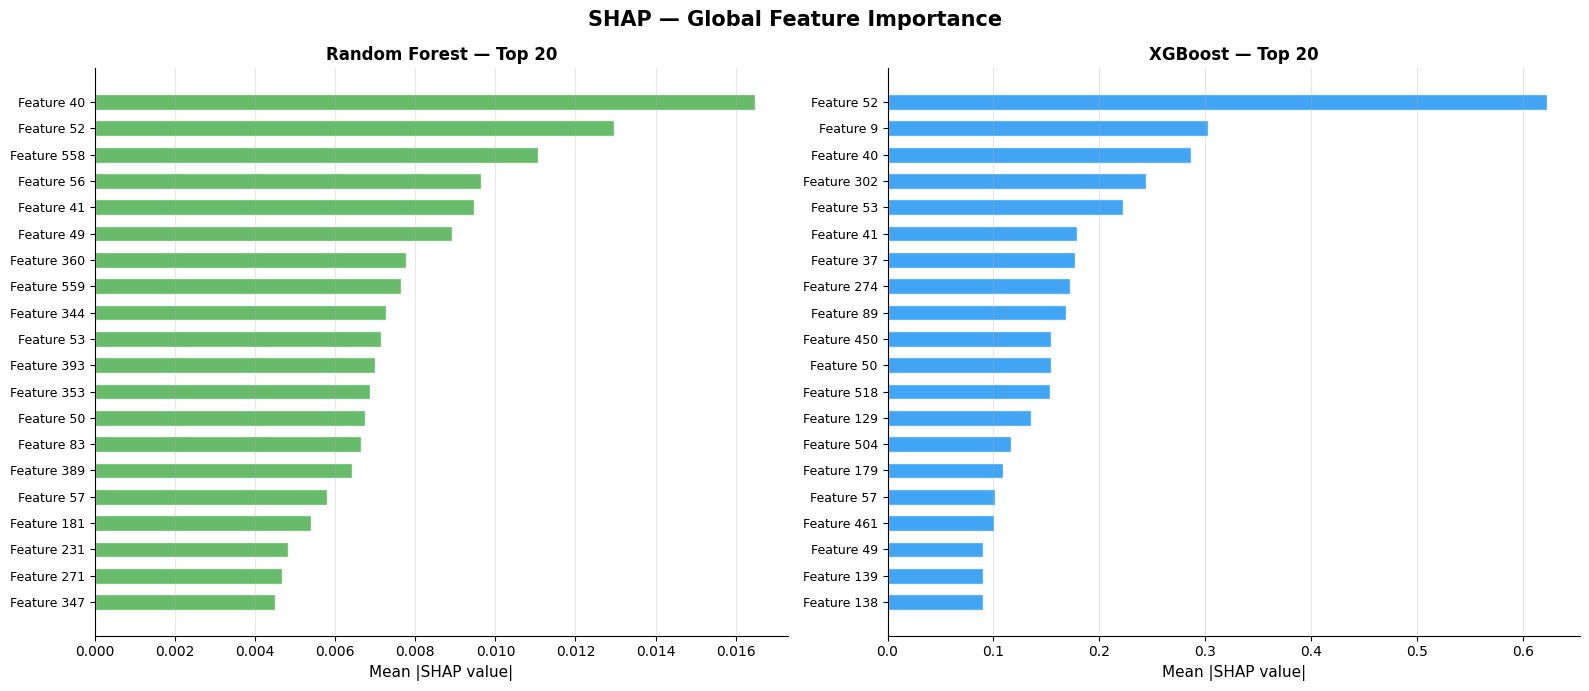

In [31]:
# ── Global feature importance bar chart ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("SHAP — Global Feature Importance", fontsize=15, fontweight='bold')

def plot_shap_importance(ax, importance, top_idx, title, color):
    plot_idx  = top_idx[:20][::-1]
    plot_vals = importance[plot_idx]
    y_pos     = list(range(20))
    ax.barh(y_pos, plot_vals.tolist(), color=color, alpha=0.85,
            edgecolor='white', height=0.6)
    ax.set_yticks(y_pos)
    ax.set_yticklabels([f"Feature {plot_idx[i]}" for i in range(20)], fontsize=9)
    ax.set_xlabel("Mean |SHAP value|", fontsize=11)
    ax.set_title(title, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='x')
    ax.spines[['top','right']].set_visible(False)

plot_shap_importance(axes[0], rf_feature_importance,  top20_rf_idx,  "Random Forest — Top 20",  '#4CAF50')
plot_shap_importance(axes[1], xgb_feature_importance, top20_xgb_idx, "XGBoost — Top 20",         '#2196F3')

plt.tight_layout()
plt.show()


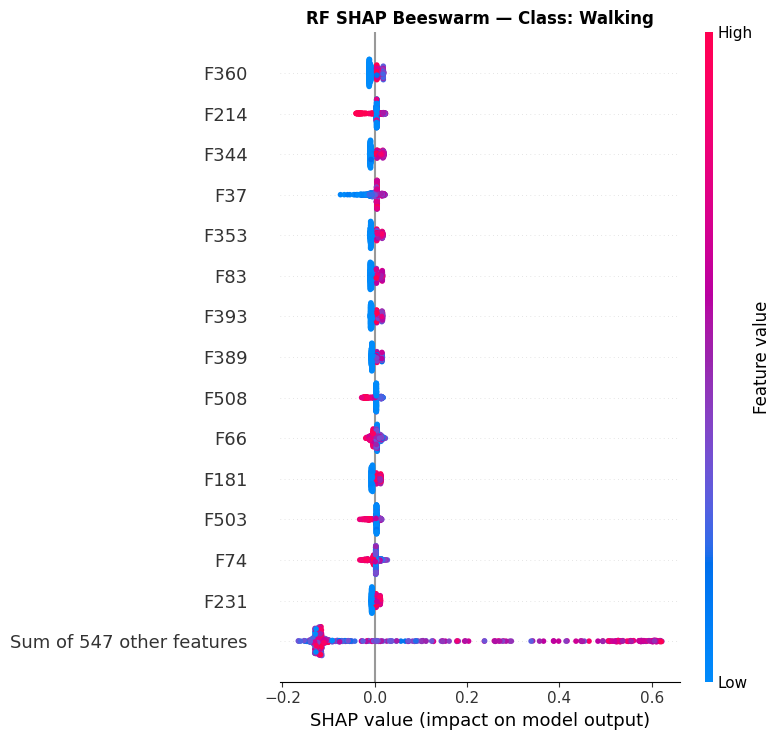

In [32]:
# ── Beeswarm — direction and magnitude for Walking class ─────
class_idx   = 0   # 0=Walking
class_names = ['Walking','Walking Upstairs','Walking Downstairs',
               'Sitting','Standing','Laying']

shap_exp_rf = shap.Explanation(
    values        = shap_values_rf[:, :, class_idx],
    base_values   = np.full(500, explainer_rf.expected_value[class_idx]),
    data          = X_shap.values,
    feature_names = [f"F{i}" for i in range(X_shap.shape[1])]
)

plt.figure(figsize=(10, 8))
shap.plots.beeswarm(shap_exp_rf, max_display=15, show=False)
plt.title(f"RF SHAP Beeswarm — Class: {class_names[class_idx]}",
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


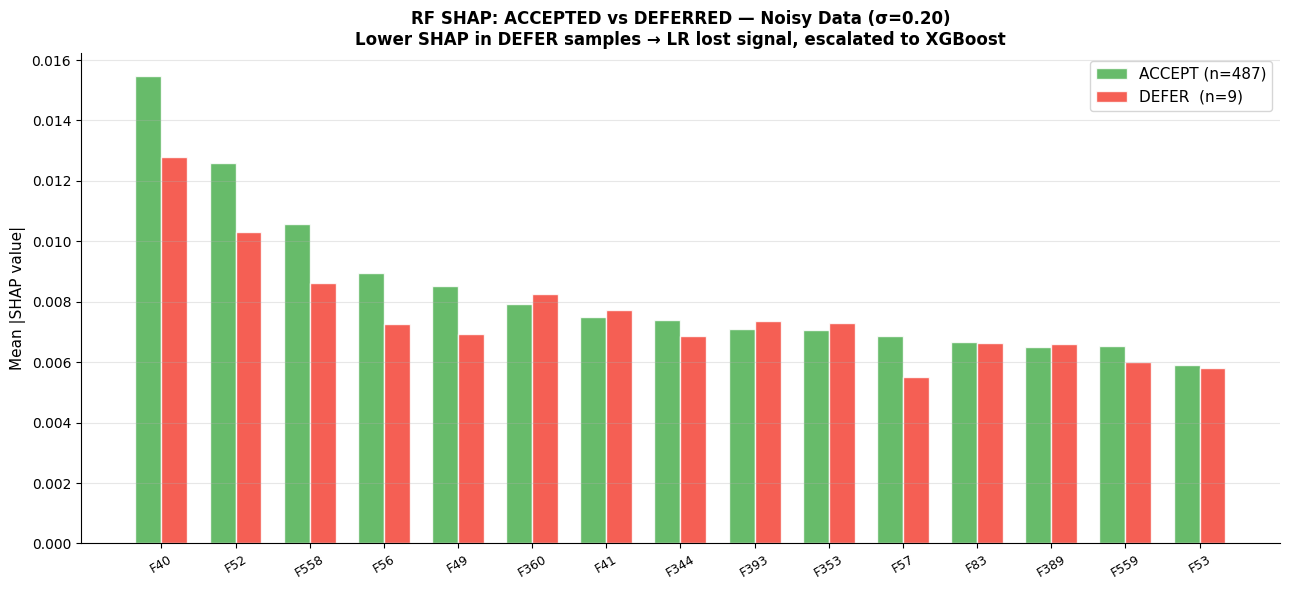

Engine on noisy data (σ=0.20):
  ACCEPT : 2002
  DEFER  : 44
  REJECT : 17


In [33]:
# ── ACCEPT vs DEFER on noisy data (σ=0.20) ──────────────────
# Clean data yields too few deferred samples (~2).
# σ=0.20 gives a meaningful number for comparison.

np.random.seed(42)
X_noisy_shap    = X_eval + np.random.normal(0, 0.20, X_eval.shape)
X_noisy_shap_df = pd.DataFrame(X_noisy_shap, columns=X_eval.columns)

proba_n  = lr_model.predict_proba(X_noisy_shap_df)
pred_n   = lr_model.predict(X_noisy_shap_df)
conf_n   = np.max(proba_n, axis=1)
xgb_pb_n = xgb_isotonic.predict_proba(X_noisy_shap_df)
xgb_cf_n = np.max(xgb_pb_n, axis=1)
xgb_pd_n = le.inverse_transform(np.argmax(xgb_pb_n, axis=1))

eng_noisy = selective_engine(conf_n, pred_n, xgb_cf_n, xgb_pd_n,
                              y_eval, best_tau_high, best_tau_low)

np.random.seed(42)
noisy_shap_idx     = np.random.choice(len(X_noisy_shap_df), size=500, replace=False)
X_shap_noisy       = X_noisy_shap_df.iloc[noisy_shap_idx].reset_index(drop=True)
decisions_noisy    = eng_noisy['decision'][noisy_shap_idx]
accept_mask_noisy  = decisions_noisy == 'accept'
defer_mask_noisy   = decisions_noisy == 'defer'

shap_noisy     = explainer_rf.shap_values(X_shap_noisy)
shap_mean_noisy = np.mean(np.abs(shap_noisy), axis=2)

accept_shap = shap_mean_noisy[accept_mask_noisy].mean(axis=0)
defer_shap  = shap_mean_noisy[defer_mask_noisy].mean(axis=0)

combined = np.maximum(accept_shap, defer_shap)
top15    = np.argsort(combined)[::-1][:15]

fig, ax = plt.subplots(figsize=(13, 6))
x, width = np.arange(15), 0.35
ax.bar(x - width/2, accept_shap[top15], width,
       label=f'ACCEPT (n={accept_mask_noisy.sum()})', color='#4CAF50', alpha=0.85, edgecolor='white')
ax.bar(x + width/2, defer_shap[top15], width,
       label=f'DEFER  (n={defer_mask_noisy.sum()})', color='#F44336', alpha=0.85, edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels([f"F{top15[i]}" for i in range(15)], rotation=30, fontsize=9)
ax.set_ylabel("Mean |SHAP value|", fontsize=11)
ax.set_title("RF SHAP: ACCEPTED vs DEFERRED — Noisy Data (σ=0.20)\n"
             "Lower SHAP in DEFER samples → LR lost signal, escalated to XGBoost",
             fontsize=12, fontweight='bold')
ax.legend(fontsize=11); ax.grid(True, alpha=0.3, axis='y')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

print(f"Engine on noisy data (σ=0.20):")
print(f"  ACCEPT : {(eng_noisy['decision']=='accept').sum()}")
print(f"  DEFER  : {(eng_noisy['decision']=='defer').sum()}")
print(f"  REJECT : {(eng_noisy['decision']=='reject').sum()}")


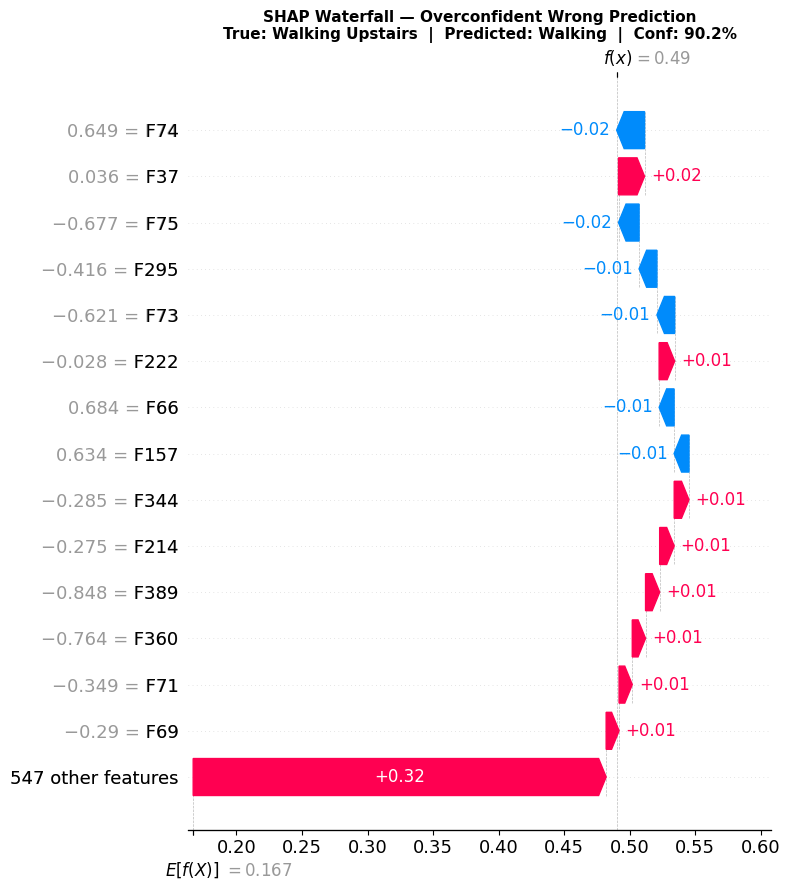


Top 6 features for predicted class 'Walking':
  Feature        Feature value   SHAP value            Direction
  --------------------------------------------------------------
  F74                  0.6494    -0.021293  ← pushes AWAY
  F37                  0.0362     0.019870  → pushes TO class
  F75                 -0.6775    -0.015696  ← pushes AWAY
  F295                -0.4160    -0.013591  ← pushes AWAY
  F73                 -0.6206    -0.013546  ← pushes AWAY
  F222                -0.0278     0.011841  → pushes TO class


In [34]:
# ── Waterfall — explain one overconfident wrong prediction ────
lr_pred_s  = lr_model.predict(X_shap)
lr_proba_s = lr_model.predict_proba(X_shap)
lr_conf_s  = np.max(lr_proba_s, axis=1)
correct_s  = (lr_pred_s == y_shap_true.values)

overconf_mask    = (lr_conf_s > 0.9) & ~correct_s
overconf_indices = np.where(overconf_mask)[0]
if len(overconf_indices) == 0:
    overconf_indices = np.where(~correct_s)[0]

sample_idx    = overconf_indices[0]
true_label    = labels[y_shap_true.iloc[sample_idx]]
pred_label    = labels[lr_pred_s[sample_idx]]
confidence    = lr_conf_s[sample_idx]
predicted_cls = lr_pred_s[sample_idx] - 1   # 0-indexed for SHAP

shap_exp_samp = shap.Explanation(
    values        = shap_values_rf[sample_idx, :, predicted_cls],
    base_values   = explainer_rf.expected_value[predicted_cls],
    data          = X_shap.iloc[sample_idx].values,
    feature_names = [f"F{i}" for i in range(X_shap.shape[1])]
)

plt.figure(figsize=(10, 7))
shap.plots.waterfall(shap_exp_samp, max_display=15, show=False)
plt.title(f"SHAP Waterfall — Overconfident Wrong Prediction\n"
          f"True: {true_label}  |  Predicted: {pred_label}  |  Conf: {confidence*100:.1f}%",
          fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

# Print actual SHAP values (avoids +0/-0 display bug in old SHAP versions)
sample_shap = shap_values_rf[sample_idx, :, predicted_cls]
top6_idx    = np.argsort(np.abs(sample_shap))[::-1][:6]
print(f"\nTop 6 features for predicted class '{pred_label}':")
print(f"  {'Feature':<12} {'Feature value':>15} {'SHAP value':>12} {'Direction':>20}")
print(f"  {'-'*62}")
for idx in top6_idx:
    direction = '→ pushes TO class' if sample_shap[idx] > 0 else '← pushes AWAY'
    print(f"  F{idx:<10} {X_shap.iloc[sample_idx, idx]:>15.4f} {sample_shap[idx]:>12.6f}  {direction}")


## 10. Final Summary

Consolidated results across all six phases.

In [35]:
print("=" * 70)
print("   FINAL PROJECT SUMMARY")
print("=" * 70)

# ── Recompute TPS across noise levels for summary ────────────
clean_noise = noise_df.iloc[0]

print(f"""
  Dataset     : UCI HAR  ({X_train.shape[0]} train, {X_eval.shape[0]} eval, {X_train.shape[1]} features)
  Pipeline    : LR → XGBoost (DEFER) → REJECT

  ── Phase 4: Baseline Models ────────────────────────────────
  Model                  Accuracy   ECE    Overconfident
  Logistic Regression    {accuracy*100:.2f}%   {ece:.4f}   {overconfident}
  Random Forest          {accuracy_rf*100:.2f}%   {ece_rf:.4f}   {overconfident_rf}

  ── Phase 5: Calibration ────────────────────────────────────
  LR  — no change needed (ECE already {ece_lr_before:.4f})
  RF  — Temperature Scaling: {ece_rf_before:.4f} → {ece_rf_ts:.4f}

  ── Phase 6: Selective Engine (clean data) ──────────────────
  tau_high = {best_tau_high:.2f}   tau_low = {best_tau_low:.2f}
  ACCEPT   {best_result['n_accept']:>6} samples
  DEFER    {best_result['n_defer']:>6} samples  (→ XGBoost)
  REJECT   {best_result['n_reject']:>6} samples  (abstain)
  Selective Accuracy : {best_result['sel_acc']*100:.2f}%
  Coverage           : {best_result['coverage']*100:.1f}%
  ECE (selective)    : {best_result['ece_sel']:.4f}
  TPS                : {best_result['tps']:.4f}

  TPS = Coverage × Selective_Accuracy / (1 + ECE)
      = {best_result['coverage']:.3f} × {best_result['sel_acc']:.4f} / (1 + {best_result['ece_sel']:.4f})
      = {best_result['tps']:.4f}

  ── Phase 7: Noise Experiments ──────────────────────────────
  σ      Accuracy    ECE       TPS
""", end='')

for _, r in noise_df.iterrows():
    print(f"  {r['sigma']:.2f}   {r['accuracy']*100:>7.2f}%  {r['ece']:.4f}  {r['tps']:.4f}")

clean_d = drift_results[0]
worst_d = drift_results[-1]
print(f"""
  ── Phase 8: Drift Detection ────────────────────────────────
  Clean (σ=0.00): KS={clean_d['_ks_obj']['mean_ks_stat']:.4f}  PSI={clean_d['_psi_obj']['mean_psi']:.4f}  {clean_d['verdict']}
  Worst (σ=0.50): KS={worst_d['_ks_obj']['mean_ks_stat']:.4f}  PSI={worst_d['_psi_obj']['mean_psi']:.4f}  {worst_d['verdict']}

  ── Phase 9: SHAP ───────────────────────────────────────────
  Top shared features (RF ∩ XGBoost top-10): {sorted(overlap)}
  Deferred samples show lower SHAP values — collectively
  ambiguous evidence triggers XGBoost escalation.

  ── Thesis ──────────────────────────────────────────────────
  Accuracy alone does not guarantee reliability.
  A trustworthy HAR system requires calibration, selective
  prediction, drift detection, and explainability working
  together as a pipeline.
""")
print("=" * 70)


   FINAL PROJECT SUMMARY

  Dataset     : UCI HAR  (7352 train, 2063 eval, 561 features)
  Pipeline    : LR → XGBoost (DEFER) → REJECT

  ── Phase 4: Baseline Models ────────────────────────────────
  Model                  Accuracy   ECE    Overconfident
  Logistic Regression    95.96%   0.0066   32
  Random Forest          92.70%   0.0942   2

  ── Phase 5: Calibration ────────────────────────────────────
  LR  — no change needed (ECE already 0.0061)
  RF  — Temperature Scaling: 0.0925 → 0.0090

  ── Phase 6: Selective Engine (clean data) ──────────────────
  tau_high = 0.55   tau_low = 0.50
  ACCEPT     2029 samples
  DEFER        25 samples  (→ XGBoost)
  REJECT        9 samples  (abstain)
  Selective Accuracy : 96.54%
  Coverage           : 99.6%
  ECE (selective)    : 0.0058
  TPS                : 0.9556

  TPS = Coverage × Selective_Accuracy / (1 + ECE)
      = 0.996 × 0.9654 / (1 + 0.0058)
      = 0.9556

  ── Phase 7: Noise Experiments ──────────────────────────────
  σ      A